# ☀️ Solar Energy Production
🇫🇷 **France — 2020 to 2026**

This notebook explores the relationship between meteorological conditions and solar energy production in France, using data from **RTE** (electricity transport network) and **Meteo-France** (weather data).

## 📁 Project Structure
```
📁 Project
├── 🗒️ solar_production
├── 🗒️ RTE_concat
└── 📁 data
    ├── 📁 coordinates
    │   ├── 📄 departements-20180101.cpg
    │   ├── 📄 departements-20180101.dbf
    │   ├── 📄 departements-20180101.prj
    │   ├── 📄 departements-20180101.shp
    │   ├── 📄 departements-20180101.shx
    │   ├── 📄 departements-descriptif.txt
    │   └── 📄 LICENCE.txt
    ├── 📁 Meteo-France
    │   ├── 📄 QUOT_SIM2_2010-2019.csv
    │   └── 📄 QUOT_SIM2_previous-2020-202605.csv
    ├── 📁 RTE
    │   ├── 📁 Regions
    │   │   ├── 📄 eCO2mix_RTE_Auvergne-Rhône-Alpes_Annuel-Definitif_2013.xls
    │   │   ├── 📄 eCO2mix_RTE_Auvergne-Rhône-Alpes_Annuel-Definitif_2014.xls
    │   │   └── 📄 ...
    │   ├── 📄 rte_regions_2013.csv
    │   ├── 📄 rte_regions_2014.csv
    │   ├── 📄 rte_regions_2015.csv
    │   ├── 📄 rte_regions_2016.csv
    │   ├── 📄 rte_regions_2017.csv
    │   ├── 📄 rte_regions_2018.csv
    │   ├── 📄 rte_regions_2019.csv
    │   ├── 📄 rte_regions_2020.csv
    │   ├── 📄 rte_regions_2021.csv
    │   ├── 📄 rte_regions_2022.csv
    │   ├── 📄 rte_regions_2023.csv
    │   ├── 📄 rte_regions_2024.csv
    │   └── 📄 rte_regions_en_cours.csv
    └── 📁 solar_installations
        └── 📄 statistiques_sdes_2026_t1_tb_dpt_installations_solaires_photovoltaiques_v2.xlsx
```

# ⬇️ 1. Modules imports & loading data 

### &nbsp;&nbsp;&nbsp; A. Modules

In [49]:
# Imports for data
import numpy as np
import pandas as pd

# Imports for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Imports for machine learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor

# Geoloc converter
import geopandas as gpd
from pyproj import Transformer

# Other
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")
import requests


### &nbsp;&nbsp;&nbsp; B. Files and settings

In [50]:
# RTE datasource: 
# https://www.rte-france.com/donnees-publications/eco2mix-donnees-temps-reel/telecharger-indicateurs
# The files used are the aggregation per year of the regions datasets
PATH_RTE = 'data/RTE/' # Change this value to link to the RTE files

# Meteo-France datasource: 
# https://www.data.gouv.fr/datasets/donnees-changement-climatique-sim-quotidienne
PATH_MF = 'data/Meteo-France/' # Change this value to link to the MF files
mf_files_name = ['QUOT_SIM2_previous-2020-202605.csv']

# Solar pannel installation over time:
# https://www.statistiques.developpement-durable.gouv.fr/tableau-de-bord-solaire-photovoltaique-premier-trimestre-2026
PATH_SOLAR_INSTALL = 'data/solar_installations/' # Change this value to link to the MF files
solar_install = 'statistiques_sdes_2026_t1_tb_dpt_installations_solaires_photovoltaiques_v2.xlsx'

# Coordinates conversion to départements and régions:
# https://www.data.gouv.fr/datasets/contours-des-departements-francais-issus-d-openstreetmap
COORDINATES = 'data/coordinates/' # Change this value to link to the MF files


# Setting up date range so both datasources match
date_min = '2020-01-01' # Lower bound included
date_max = '2026-02-01' # Upper bound NOT included

# Setting up region dict so all our data are consistent and geo-compatible
region_dict = {
    "Auvergne-Rhône-Alpes"          : "Auvergne-Rhône-Alpes", # Solar installations + RTE
    "Bourgogne-Franche-Comté"       : "Bourgogne-Franche-Comté", # Solar installations + RTE
    "Bretagne"                      : "Bretagne", # Solar installations + RTE
    "Centre-Val de Loire"           : "Centre-Val de Loire", # Solar installations
    "Centre-Val-de-Loire"           : "Centre-Val de Loire", # RTE  
    "Grand Est"                     : "Grand Est", # Solar installations
    "Grand-Est"                     : "Grand Est", # RTE  
    "Hauts-de-France"               : "Hauts-de-France", # Solar installations + RTE
    "Normandie"                     : "Normandie", # Solar installations + RTE
    "Nouvelle-Aquitaine"            : "Nouvelle-Aquitaine", # Solar installations + RTE
    "Occitanie"                     : "Occitanie", # Solar installations + RTE
    "Pays de la Loire"              : "Pays de la Loire", # Solar installations
    "Pays-de-la-Loire"              : "Pays de la Loire", # RTE 
    "Provence-Alpes-Côte d'Azur"    : "Provence-Alpes-Côte d'Azur", # Solar installations
    "PACA"                          : "Provence-Alpes-Côte d'Azur", # RTE 
    "Île-de-France"                 : "Île-de-France", # Solar installations
    "Ile-de-France"                 : "Île-de-France", # RTE 
    "Auvergne-Rhône-Alpes"          : "Auvergne-Rhône-Alpes", # Solar installations
    "Auvergne-Rhône-Alpes"          : "Auvergne-Rhône-Alpes", # RTE
    "Corse"                         : "Corse",
}

### &nbsp;&nbsp;&nbsp; C. Loading RTE data

In [51]:
# Loading dataset
# The files are the aggratation per year and by region of the datasets provided by RTE
# The conversion can be done with RTE_concat notebook
df_list = []
for year in range(2020, 2025):
    file = f"{PATH_RTE}rte_regions_{year}.csv"
    # index_col=False to avoid column name offset
    # usecols to keep only the solar relative data
    # parse_dates to get proper date format while loading
    df = pd.read_csv(file, sep=",", encoding="utf-8", index_col=False, usecols=['Date', 'Solaire', 'region'], parse_dates=['Date'])
    df_list.append(df)

# Adding the current not consolidated data > 2024
current = f"{PATH_RTE}rte_regions_en_cours.csv"
df = pd.read_csv(current, sep=",", encoding="utf-8", index_col=False, usecols=['Date', 'Solaire', 'region'], parse_dates=['Date'])
df = df[df['Date'] <= date_max] # Keeping until the date_max we setted up earlier
df_list.append(df)

rte_df = pd.concat(df_list, ignore_index=True)
rte_df = rte_df.dropna(subset=['Solaire']) # Droping rows without measurements

# Converting regions' name
rte_df['region'] = rte_df['region'].map(region_dict)

print('RTE data successfully loaded !')

RTE data successfully loaded !


### &nbsp;&nbsp;&nbsp; D. Reshaping RTE data

In [52]:
# Converting to TWh: more readable and understandable than raw production
# Multipling by 0.5 because it's half an hour value to get TWh
# Divide by 1_000_000 to get TWh instead of MWh for readability
# Terrawatts hour = Megawatts × Hours / 1_000_000
rte_df['TWh'] = rte_df['Solaire'] * 0.5 / 1_000_000

# Grouping data by date
rte_df = rte_df.groupby(['Date','region'])[['Solaire', 'TWh']].sum().reset_index()
print('RTE data reshaped successfully !')

RTE data reshaped successfully !


### &nbsp;&nbsp;&nbsp; E. Loading solar installations data

In [53]:
# Load the data, there's 2 headers...
solar_install_df = pd.read_excel(f'{PATH_SOLAR_INSTALL}{solar_install}', header=[2, 3])

# Dropping unused values
solar_install_df = solar_install_df[
    solar_install_df.iloc[:, 0].notna() &                                   # Keep rows with region name
    solar_install_df.iloc[:, 2].isna() &                                    # Exclude overseas: only rows that are not na
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('Total') &      # Remove Total rows
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('Le parc') &    # Remove footnote 'Le parc...'
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('p :') &        # Remove footnote 'p :...'
    ~solar_install_df.iloc[:, 0].astype(str).str.startswith('Source')       # Remove footnote 'Source...'
].iloc[:, [0] + list(range(3, len(solar_install_df.columns)))]              # Remove col 1 and 2 (départements str and id)


# Rename the region column
solar_install_df = solar_install_df.rename(columns={'Unnamed: 0_level_0': 'region'}, level=0)
solar_install_df = solar_install_df.rename(columns={'Unnamed: 0_level_1': 'region'}, level=1)


# Set region as index
solar_install_df = solar_install_df.set_index(('region', 'region'))
solar_install_df.index.name = 'region'


# Stack date level into rows
solar_install_df = (solar_install_df
                      .stack(level=0) # Brings the dates down as rows, leaving nombre and puissance as columns
                      .reset_index()
                      .rename(columns={'level_1': 'date'})
                     )


# Resample to daily, forward fill
solar_install_df = solar_install_df.set_index('date')

solar_install_daily = (solar_install_df
                    .drop(columns='region')          # Avoid duplicated region column
                    .groupby(solar_install_df['region'])
                    .resample('D')
                    .ffill()
                    .reset_index())

# Doing this after the forward fill to avoid start in the first day of the year
# Keep only the dates boundaries
solar_install_daily = solar_install_daily[(solar_install_daily['date'] >= date_min) & 
                                     (solar_install_daily['date'] < date_max)
                                     ]

# Converting regions' name
solar_install_daily['region'] = solar_install_daily['region'].map(region_dict)

print('Solar installations data successfully loaded !')

Solar installations data successfully loaded !


### &nbsp;&nbsp;&nbsp; F. Getting all geoloc combinaisons in our Météo-France data

In [54]:
# Loading data
df_list = []
for files in mf_files_name:
    file = f"{PATH_MF}{files}"
    # Reading the file by chunks to get a smooth data loading 
    # Keeping only X and Y coordinates
    for chunk in pd.read_csv(file, sep=';', index_col=False, chunksize=100_000, usecols=['LAMBX', 'LAMBY']):
        df_list.append(chunk)

geo_loc_df = pd.concat(df_list, ignore_index=True)

# Keeping all X and Y combinations into 1 dataframe to get the associated region
geo_loc_df.drop_duplicates(inplace=True)

print('Coordinates successfully loaded !')

Coordinates successfully loaded !


### &nbsp;&nbsp;&nbsp; G. Converting coordinates 

In [55]:
# ── Step 1: Define the coordinate transformer ──────────────────────────────────
# Meteo-France uses Lambert II étendu (EPSG:27572), a French grid projection
# We convert to WGS84 (EPSG:4326) which is the standard GPS lat/lon system
transformer = Transformer.from_crs("EPSG:27572", "EPSG:4326", always_xy=True)

# ── Step 2: Get unique grid points ─────────────────────────────────────────────
# The MF dataset has 50M+ rows but only 9892 unique LAMBX/LAMBY combinations
# Working on unique coordinates is much faster than converting every row
coords = geo_loc_df[['LAMBX', 'LAMBY']].drop_duplicates()

# ── Step 3: Convert Lambert coordinates to GPS lon/lat ─────────────────────────
# MF stores coordinates in decameters (units of 10m), so multiply by 100
# to get meters which is what the transformer expects
# always_xy=True ensures the order is always (longitude, latitude)
coords['lon'], coords['lat'] = transformer.transform(
    coords['LAMBX'] * 100,
    coords['LAMBY'] * 100
)

# ── Step 4: Create a GeoDataFrame from the coordinates ─────────────────────────
# GeoDataFrame is like a regular DataFrame but with a geometry column
# points_from_xy() creates Point objects from lon/lat columns
# crs="EPSG:4326" tells geopandas these are GPS coordinates
coords_gdf = gpd.GeoDataFrame(
    coords,
    geometry=gpd.points_from_xy(coords['lon'], coords['lat']),
    crs="EPSG:4326"
)

### &nbsp;&nbsp;&nbsp; H. Loading départements shapes and matching coordinates to départements

In [56]:
# ── Step 5: Load département boundaries ────────────────────────────────────────
# The shapefile contains polygon geometries of all French départements
# .to_crs("EPSG:4326") reprojects the shapefile to GPS coordinates
# so both GeoDataFrames use the same coordinate system for the join
departements = gpd.read_file('data/coordinates/departements-20180101.shp').to_crs("EPSG:4326")

# ── Step 6: Spatial join — point in polygon ────────────────────────────────────
# For each point in coords_gdf, find which département polygon it falls inside
# how='left' keeps all points even if no département is found
# predicate='within' means: the point must be strictly inside the polygon
coords_with_dep = gpd.sjoin(coords_gdf, departements, how='left', predicate='within')

# ── Step 7: Handle unmatched points ───────────────────────────────────────────
# Some points fall on borders or just outside polygons (coastal points, etc.)
# and get NaN for code_insee — split matched vs unmatched
matched   = coords_with_dep[coords_with_dep['code_insee'].notna()]
unmatched = coords_with_dep[coords_with_dep['code_insee'].isna()][['LAMBX', 'LAMBY', 'lon', 'lat', 'geometry']]

# For unmatched points, use nearest département instead of strict containment
# sjoin_nearest finds the closest polygon even if the point is outside it
unmatched_fixed = gpd.sjoin_nearest(unmatched, departements, how='left')

# ── Step 8: Combine and verify ─────────────────────────────────────────────────
# Merge matched and nearest-fixed rows back together
coords_to_region = pd.concat([matched, unmatched_fixed], ignore_index=True)
coords_to_region.drop(columns=['geometry', 'index_right', 'nuts3', 'wikipedia', 'surf_km2', 'nom', 'lon', 'lat'], inplace=True)

### &nbsp;&nbsp;&nbsp; I. Converting départements to région to match RTE's data

In [57]:
# Converting départements to région to match RTE's data
dept_to_region = {
    # Auvergne-Rhône-Alpes
    '01': 'Auvergne-Rhône-Alpes', '03': 'Auvergne-Rhône-Alpes',
    '07': 'Auvergne-Rhône-Alpes', '15': 'Auvergne-Rhône-Alpes',
    '26': 'Auvergne-Rhône-Alpes', '38': 'Auvergne-Rhône-Alpes',
    '42': 'Auvergne-Rhône-Alpes', '43': 'Auvergne-Rhône-Alpes',
    '63': 'Auvergne-Rhône-Alpes', '69': 'Auvergne-Rhône-Alpes',
    '69D': 'Auvergne-Rhône-Alpes',  # Rhône hors métropole
    '69M': 'Auvergne-Rhône-Alpes',  # Métropole de Lyon
    '73': 'Auvergne-Rhône-Alpes', '74': 'Auvergne-Rhône-Alpes',

    # Bourgogne-Franche-Comté
    '21': 'Bourgogne-Franche-Comté', '25': 'Bourgogne-Franche-Comté',
    '39': 'Bourgogne-Franche-Comté', '58': 'Bourgogne-Franche-Comté',
    '70': 'Bourgogne-Franche-Comté', '71': 'Bourgogne-Franche-Comté',
    '89': 'Bourgogne-Franche-Comté', '90': 'Bourgogne-Franche-Comté',

    # Bretagne
    '22': 'Bretagne', '29': 'Bretagne', '35': 'Bretagne', '56': 'Bretagne',

    # Centre-Val de Loire
    '18': 'Centre-Val de Loire', '28': 'Centre-Val de Loire',
    '36': 'Centre-Val de Loire', '37': 'Centre-Val de Loire',
    '41': 'Centre-Val de Loire', '45': 'Centre-Val de Loire',

    # Grand Est
    '08': 'Grand Est', '10': 'Grand Est', '51': 'Grand Est',
    '52': 'Grand Est', '54': 'Grand Est', '55': 'Grand Est',
    '57': 'Grand Est', '67': 'Grand Est', '68': 'Grand Est',
    '88': 'Grand Est',

    # Hauts-de-France
    '02': 'Hauts-de-France', '59': 'Hauts-de-France',
    '60': 'Hauts-de-France', '62': 'Hauts-de-France', '80': 'Hauts-de-France',

    # Île-de-France
    '75': 'Île-de-France', '77': 'Île-de-France', '78': 'Île-de-France',
    '91': 'Île-de-France', '92': 'Île-de-France', '93': 'Île-de-France',
    '94': 'Île-de-France', '95': 'Île-de-France',

    # Normandie
    '14': 'Normandie', '27': 'Normandie', '50': 'Normandie',
    '61': 'Normandie', '76': 'Normandie',

    # Nouvelle-Aquitaine
    '16': 'Nouvelle-Aquitaine', '17': 'Nouvelle-Aquitaine',
    '19': 'Nouvelle-Aquitaine', '23': 'Nouvelle-Aquitaine',
    '24': 'Nouvelle-Aquitaine', '33': 'Nouvelle-Aquitaine',
    '40': 'Nouvelle-Aquitaine', '47': 'Nouvelle-Aquitaine',
    '64': 'Nouvelle-Aquitaine', '79': 'Nouvelle-Aquitaine',
    '86': 'Nouvelle-Aquitaine', '87': 'Nouvelle-Aquitaine',

    # Occitanie
    '09': 'Occitanie', '11': 'Occitanie', '12': 'Occitanie',
    '30': 'Occitanie', '31': 'Occitanie', '32': 'Occitanie',
    '34': 'Occitanie', '46': 'Occitanie', '48': 'Occitanie',
    '65': 'Occitanie', '66': 'Occitanie', '81': 'Occitanie',
    '82': 'Occitanie',

    # Provence-Alpes-Côte d"Azur
    "04": "Provence-Alpes-Côte d'Azur", "05": "Provence-Alpes-Côte d'Azur", 
    "06": "Provence-Alpes-Côte d'Azur", "13": "Provence-Alpes-Côte d'Azur", 
    "83": "Provence-Alpes-Côte d'Azur", "84": "Provence-Alpes-Côte d'Azur",

    # Corse
    '2A': 'Corse', '2B': 'Corse',

    # Pays de la Loire
    '44': 'Pays de la Loire', '49': 'Pays de la Loire', '53': 'Pays de la Loire', 
    '72': 'Pays de la Loire', '85': 'Pays de la Loire',
}

coords_to_region['region'] = coords_to_region['code_insee'].map(dept_to_region)
print(f'Number of départements not match to a region: {coords_to_region['region'].isna().sum()}')  # should be 0
if coords_to_region['region'].isna().sum() == 0:
    print(f'Coordinates to region data successfully calculated and loaded')

Number of départements not match to a region: 0
Coordinates to region data successfully calculated and loaded


### &nbsp;&nbsp;&nbsp; J. Loading Météo-France data

In [58]:
# The goal is to load a chunk of data, get the associated region and aggregate it directly
# This way the loading process is way more memory efficient
# Loading data
df_list = []
for files in mf_files_name:
    file = f"{PATH_MF}{files}"
    year_chunks = []
    for chunk in pd.read_csv(file, sep=';', index_col=False, chunksize=100_000, parse_dates=['DATE']):
        filtered = chunk[
            (chunk['DATE'] >= date_min) &
            (chunk['DATE'] < date_max)
        ]
        # Getting region then filtering and aggregating result per year so we don't have trunkated results
        filtered = filtered.merge(coords_to_region, on=['LAMBX', 'LAMBY'], how='left')
        filtered = filtered.loc[filtered['region'] != 'Corse'].drop(columns=['LAMBX', 'LAMBY'])
        year_chunks.append(filtered)

    # Aggregate only after all chunks of the file are loaded
    year_mf_df = pd.concat(year_chunks, ignore_index=True)
    year_mf_df = year_mf_df.groupby(['DATE', 'region']).mean(numeric_only=True).reset_index()
    df_list.append(year_mf_df)
    del year_chunks, year_mf_df # freeing memory before next file

mf_df = pd.concat(df_list, ignore_index=True)
print('Meteo-France data successfully loaded !')

Meteo-France data successfully loaded !


### &nbsp;&nbsp;&nbsp; K. Merging data

In [59]:
# Merging RTE data into our météo-France dataset
solar_prod_df = (mf_df
                 .merge(rte_df, how='left', left_on=['DATE','region'], right_on=['Date','region'])
                 .drop(columns='Date') # Dropping RTE's Date column: not needed we already have a DATE field from MF
                 )

# Merging solar installations data into our météo-France dataset
solar_prod_df = (solar_prod_df
                 .merge(solar_install_daily, how='left', left_on=['DATE', 'region'], right_on=['date', 'region'])
                 .drop(columns='date') # Dropping solar installations date column: not needed we already have a DATE field from MF
                 )

print("RTE's data and solar production data successfully integrated !")

RTE's data and solar production data successfully integrated !


### &nbsp;&nbsp;&nbsp; K. Getting regions' properties from a geojson for mapping

In [60]:
# Load France regions GeoJSON directly from the web
geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/regions-version-simplifiee.geojson"
geojson = requests.get(geojson_url).json()

# Getting Geojson regions' name
geojson_regions = [feature['properties']['nom'] for feature in geojson['features']]

### &nbsp;&nbsp;&nbsp; L. Renaming columns

In [61]:
# Renaming columns to make it clearer for everybody
rename_dict = {
    "DATE"              : "date",
    "region"            : "region",
    "PRENEI"            : "snowfall",
    "PRELIQ"            : "rainfall",
    "T"                 : "daily_avg_temp",
    "FF"                : "daily_avg_wind_speed",
    "Q"                 : "daily_avg_specific_humidity",
    "DLI"               : "atmospheric_radiation",
    "SSI"               : "visible_radiation",
    "HU"                : "daily_avg_relative_humidity",
    "EVAP"              : "total_evapotranspiration",
    "ETP"               : "potential_evapotranspiration",
    "PE"                : "effective_rainfall",
    "SWI"               : "daily_avg_soil_moisture_index",
    "SSWI_10J"          : "soil_drought_index_10d",
    "DRAINC"            : "drainage",
    "RUNC"              : "runoff",
    "RESR_NEIGE"        : "daily_avg_snow_water",
    "RESR_NEIGE6"       : "snow_water_equivalent_6h",
    "HTEURNEIGE"        : "daily_avg_snow_depth",
    "HTEURNEIGE6"       : "snow_depth_6h",
    "HTEURNEIGEX"       : "max_snow_depth",
    "SNOW_FRAC"         : "daily_avg_snow_cover_fraction",
    "ECOULEMENT"        : "snowmelt_runoff",
    "WG_RACINE"         : "root_liquid_water",
    "WGI_RACINE"        : "root_frozen_water",
    "TINF_H"            : "min_temp",
    "TSUP_H"            : "max_temp",
    "Solaire"           : "solar",
    "nombre"            : "installation_number",
    "puissance"         : "capacity_power",
}

solar_prod_df.rename(columns=rename_dict, inplace=True)

# Sorting values
solar_prod_df = solar_prod_df.sort_values(["date", 'region']).reset_index(drop=True)

### &nbsp;&nbsp;&nbsp; M. Exporting dataset

In [62]:
# Export all operation into a file for easier manipulation
solar_prod_df.to_csv('solar_production.csv', index=False)
print("The dataset has been saved into 'solar_production.csv' !")

The dataset has been saved into 'solar_production.csv' !


In [63]:
solar_prod_df['region'].unique()

<ArrowStringArray>
[      'Auvergne-Rhône-Alpes',    'Bourgogne-Franche-Comté',
                   'Bretagne',        'Centre-Val de Loire',
                  'Grand Est',            'Hauts-de-France',
                  'Normandie',         'Nouvelle-Aquitaine',
                  'Occitanie',           'Pays de la Loire',
 'Provence-Alpes-Côte d'Azur',              'Île-de-France']
Length: 12, dtype: str

## 📊 2. Dataset Description
| Column | Description | Unit | Precision | Source |
|--------|-------------|------|-----------|--------|
| date | Measurement date | YYYYMMDD | - | 🌤️ Meteo-France |
| region | French administrative region | - | - |  🔮 Engineered  |
| snowfall | Solid precipitation (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| rainfall | Liquid precipitation (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_temp | Average daily temperature (00UTC-00UTC) | °C | 1/10 | 🌤️ Meteo-France |
| daily_avg_wind_speed | Average daily wind speed (00UTC-00UTC) | m/s | 1/10 | 🌤️ Meteo-France |
| daily_avg_specific_humidity | Specific humidity (00UTC-00UTC) | g/kg | - | 🌤️ Meteo-France |
| atmospheric_radiation | Atmospheric radiation (daily cumul 00UTC-00UTC) | J/cm² | - | 🌤️ Meteo-France |
| visible_radiation | Visible radiation (daily cumul 00UTC-00UTC) | J/cm² | - | 🌤️ Meteo-France |
| daily_avg_relative_humidity | Relative humidity (00UTC-00UTC) | % | - | 🌤️ Meteo-France |
| total_evapotranspiration | Total evapotranspiration (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| potential_evapotranspiration | Potential evapotranspiration - Penman-Monteith FAO-56 | mm | 1/10 | 🌤️ Meteo-France |
| effective_rainfall | Effective rainfall (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_soil_moisture_index | Soil moisture index (06UTC-06UTC) | % | - | 🌤️ Meteo-France |
| soil_drought_index_10d | 10-day integrated soil drought index | - | - | 🌤️ Meteo-France |
| drainage | Drainage (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| runoff | Runoff (daily cumul 06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_snow_water | Snow water equivalent - daily average (06UTC-06UTC) | mm | 1/10 | 🌤️ Meteo-France |
| snow_water_equivalent_6h | Snow water equivalent at 06UTC | mm | 1/10 | 🌤️ Meteo-France |
| daily_avg_snow_depth | Snow depth - daily average (06UTC-06UTC) | m | - | 🌤️ Meteo-France |
| snow_depth_6h | Snow depth at 06UTC | m | - | 🌤️ Meteo-France |
| max_snow_depth | Maximum hourly snow depth during the day | m | - | 🌤️ Meteo-France |
| daily_avg_snow_cover_fraction | Snow cover fraction - daily average (06UTC-06UTC) | % | - | 🌤️ Meteo-France |
| snowmelt_runoff | Runoff at the base of the snowpack (daily cumul 06UTC-06UTC) | mm | - | 🌤️ Meteo-France |
| root_liquid_water | Liquid water content in root layer at 06UTC | m³/m³ | - | 🌤️ Meteo-France |
| root_frozen_water | Frozen water content in root layer at 06UTC | m³/m³ | - | 🌤️ Meteo-France |
| min_temp | Minimum temperature over 24h (18UTC-18UTC) | °C | 1/10 | 🌤️ Meteo-France |
| max_temp | Maximum temperature over 24h (06UTC-06UTC) | °C | 1/10 | 🌤️ Meteo-France |
| solar | Solar power production | MW | - | ⚡ RTE |
| TWh | Solar power production | TWh | - | ⚡ RTE |
| installation_number | Number of connected solar installations | - | - | ☀️ SDES |
| capacity_power | Installed solar capacity | MW | - | ☀️ SDES |

# 📈 3. EDA 

### &nbsp;&nbsp;&nbsp; A. Basic stats

In [64]:
# Basic stats
print("Number of rows : {}".format(solar_prod_df.shape[0]))
print()

pd.set_option('display.max_columns', None) # Displays all columns and avoids truncated display
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format) # Avoid scientific notation for numbers

print("Display of dataset: ")
display(solar_prod_df.head())
print()

print("Basics statistics: ")
data_desc = solar_prod_df.describe(include='all')
display(data_desc)
print()

print("Percentage of missing values: ")
missing_pct = (100 * solar_prod_df.isnull().sum() / solar_prod_df.shape[0]).round(2)

display(missing_pct.sort_values(ascending=False).to_frame(name='Missing %'))

print("Values types: ")
display(solar_prod_df.dtypes.to_frame(name='Type'))

Number of rows : 26676

Display of dataset: 


,date,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,potential_evapotranspiration,effective_rainfall,daily_avg_soil_moisture_index,soil_drought_index_10d,drainage,runoff,daily_avg_snow_water,snow_water_equivalent_6h,daily_avg_snow_depth,snow_depth_6h,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,solar,TWh,installation_number,capacity_power
0,2020-01-01,Auvergne-Rhône-Alpes,0.01,0.02,1.40,1.01,3.44,2372.14,638.45,76.01,0.29,0.31,-0.25,0.94,1.01,2.18,0.03,80.95,81.04,0.25,0.25,0.25,0.18,0.13,0.30,0.01,-0.99,4.79,3219.00,0.00,81971.00,1129.45
1,2020-01-01,Bourgogne-Franche-Comté,0.00,0.72,0.30,1.22,3.82,2680.89,328.01,94.14,0.19,0.20,0.53,1.02,1.15,2.47,0.06,1.57,1.58,0.01,0.01,0.01,0.02,0.01,0.33,0.00,-2.20,3.21,304.00,0.00,25497.00,303.56
2,2020-01-01,Bretagne,0.00,0.44,8.79,1.38,6.92,3130.60,99.87,98.00,0.16,0.35,0.28,0.96,0.87,2.27,0.18,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.31,0.00,7.33,9.88,206.00,0.00,23771.00,247.79
3,2020-01-01,Centre-Val de Loire,0.00,3.37,5.12,2.25,5.47,2963.49,183.62,98.23,0.20,0.24,3.18,0.97,1.26,1.10,0.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.31,0.00,0.88,7.49,240.00,0.00,19723.00,345.25
4,2020-01-01,Grand Est,0.02,0.16,0.26,1.76,3.43,2467.23,349.46,85.77,0.15,0.27,0.02,0.96,0.67,1.72,0.01,34.97,35.01,0.12,0.12,0.12,0.09,0.08,0.31,0.00,-1.06,2.22,504.00,0.00,40903.00,575.95



Basics statistics: 


,date,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,potential_evapotranspiration,effective_rainfall,daily_avg_soil_moisture_index,soil_drought_index_10d,drainage,runoff,daily_avg_snow_water,snow_water_equivalent_6h,daily_avg_snow_depth,snow_depth_6h,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,solar,TWh,installation_number,capacity_power
count,26676,26676,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00,26676.00
unique,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Auvergne-Rhône-Alpes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2023-01-16 00:00:00,NaN,0.14,2.33,11.76,2.96,7.20,2838.77,1198.92,78.05,1.49,2.15,0.98,0.64,-0.05,0.72,0.27,7.43,7.46,0.02,0.02,0.02,0.03,0.17,0.27,0.00,8.41,15.54,9462.87,0.00,65021.12,1429.94
min,2020-01-01 00:00:00,NaN,0.00,0.00,-6.96,0.59,1.47,1660.17,52.25,32.91,-0.31,0.11,-6.43,0.06,-2.59,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.18,0.00,-9.66,-4.84,15.00,0.00,16960.00,128.27
25%,2021-07-09 00:00:00,NaN,0.00,0.04,7.06,1.90,5.18,2638.40,489.08,70.91,0.65,0.81,-1.50,0.42,-0.68,0.29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.24,0.00,4.06,10.13,1851.00,0.00,30488.00,427.69
50%,2023-01-16 00:00:00,NaN,0.00,0.40,11.51,2.62,6.93,2864.01,1036.95,79.91,1.28,1.74,-0.36,0.67,-0.08,0.49,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.27,0.00,8.50,15.12,4966.00,0.00,49391.00,941.04
75%,2024-07-25 00:00:00,NaN,0.00,2.94,16.72,3.68,9.09,3066.02,1772.01,86.52,2.14,3.16,1.88,0.85,0.52,0.95,0.29,2.06,2.14,0.01,0.01,0.01,0.01,0.10,0.30,0.00,13.08,20.92,12805.25,0.01,85734.00,2095.82
max,2026-01-31 00:00:00,NaN,16.98,61.77,31.02,11.35,16.69,3567.06,3314.62,99.00,6.45,9.22,61.49,1.19,4.01,7.28,10.38,132.51,132.89,0.38,0.39,0.39,0.74,10.65,0.35,0.03,23.84,38.32,85858.00,0.04,232304.00,6880.52



Percentage of missing values: 


,Missing %
date,0.00
region,0.00
snowfall,0.00
rainfall,0.00
daily_avg_temp,0.00
daily_avg_wind_speed,0.00
daily_avg_specific_humidity,0.00
atmospheric_radiation,0.00
visible_radiation,0.00
daily_avg_relative_humidity,0.00


Values types: 


,Type
date,datetime64[us]
region,str
snowfall,float64
rainfall,float64
daily_avg_temp,float64
daily_avg_wind_speed,float64
daily_avg_specific_humidity,float64
atmospheric_radiation,float64
visible_radiation,float64
daily_avg_relative_humidity,float64


### &nbsp;&nbsp;&nbsp; B. Setting up visualization modules

In [65]:
# Reseting previous options
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')
pd.reset_option('display.float_format')

# Configuration
palette = ["#345fff", "#e142d5", "#ff4b9b", 
           "#ffc352", "#f9f871", "#9bde7e", 
           "#4bbc8e", "#039590", "#1c6e7d", "#2f4858", ]

sns.set_theme(style="darkgrid", palette=palette)

# Colors
ACCENT_BLUE  = palette[0]
ACCENT_RED   = palette[2]
ACCENT_GREEN = palette[7]

### &nbsp;&nbsp;&nbsp; C. Solar energy production

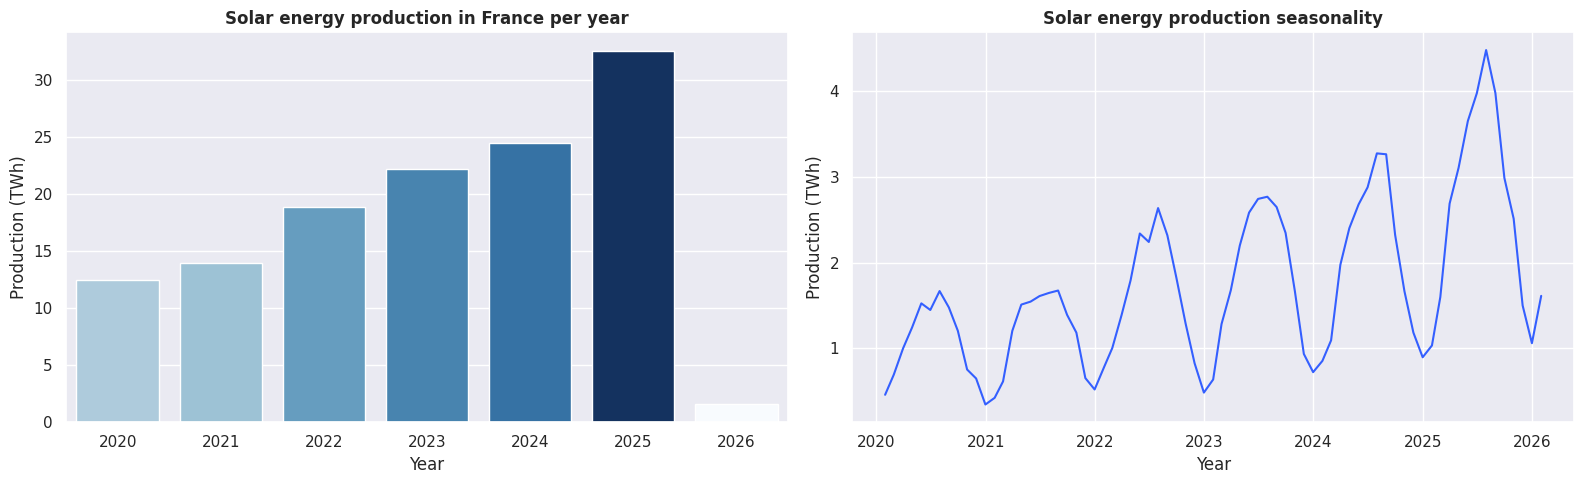

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Energy consumption
yearly_df = (solar_prod_df
             .groupby(solar_prod_df['date'].dt.to_period('Y'))['TWh'] # Using dt.to_period to get clean labels
             .sum()
             .reset_index()
             )

sns.barplot(data=yearly_df,
            x='date', 
            y='TWh',
            hue='TWh',
            palette='Blues', 
            ax=axes[0])

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Production (TWh)")
axes[0].set_title("Solar energy production in France per year", fontweight="bold")
axes[0].legend().remove()


monthly_df = (solar_prod_df
              .groupby(pd.Grouper(key='date', freq='ME'))['TWh']
              .sum()
              .reset_index()
              )

sns.lineplot(data=monthly_df,
            x='date', 
            y='TWh',
            palette='Blues',
            ax=axes[1])

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Production (TWh)")
axes[1].set_title("Solar energy production seasonality", fontweight="bold")


plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; D. Evolution of solar production by months

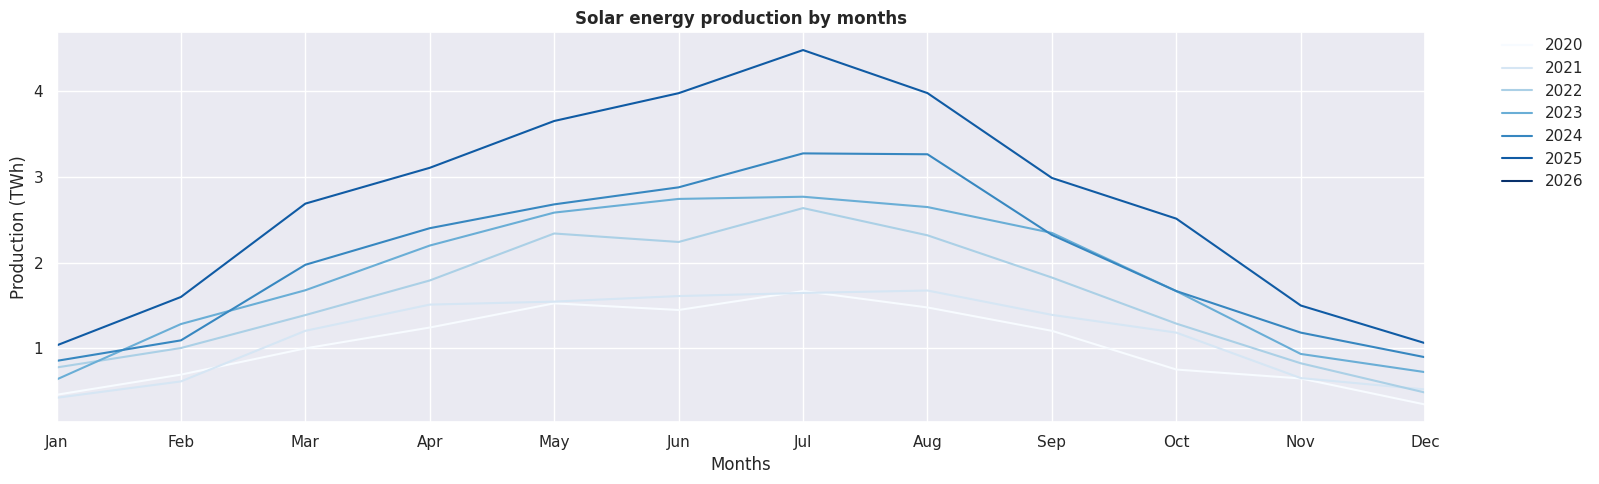

In [67]:
month_year_df = (solar_prod_df
              .groupby([solar_prod_df['date'].dt.to_period('M')])['TWh']
              .sum()
              .reset_index()
              )

month_year_df['date'] = month_year_df['date'].dt.to_timestamp()
month_year_df['year'] = month_year_df['date'].dt.year
month_year_df['month'] = month_year_df['date'].dt.month


fig, ax = plt.subplots(figsize=(16, 5))
sns.lineplot(data=month_year_df,
                x='month', 
                y='TWh', 
                hue='year',
                palette='Blues',
                markers=True,
                dashes=False,
                ax=ax
                )

ax.set_xlabel("Months")
ax.set_ylabel("Production (TWh)")
ax.set_title("Solar energy production by months", fontweight="bold")

ax.margins(x=0) # To start the graph at the Y axis and leave no space

plt.legend(bbox_to_anchor=(1.12, 1), borderaxespad=0, frameon=False) # Put legend out of the graph

# Show all x labels and customize the labels
ax.set_xticks(range(1, 13)) # Setting up 12 marks
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; E. Solar production and atmospheric radiation relation

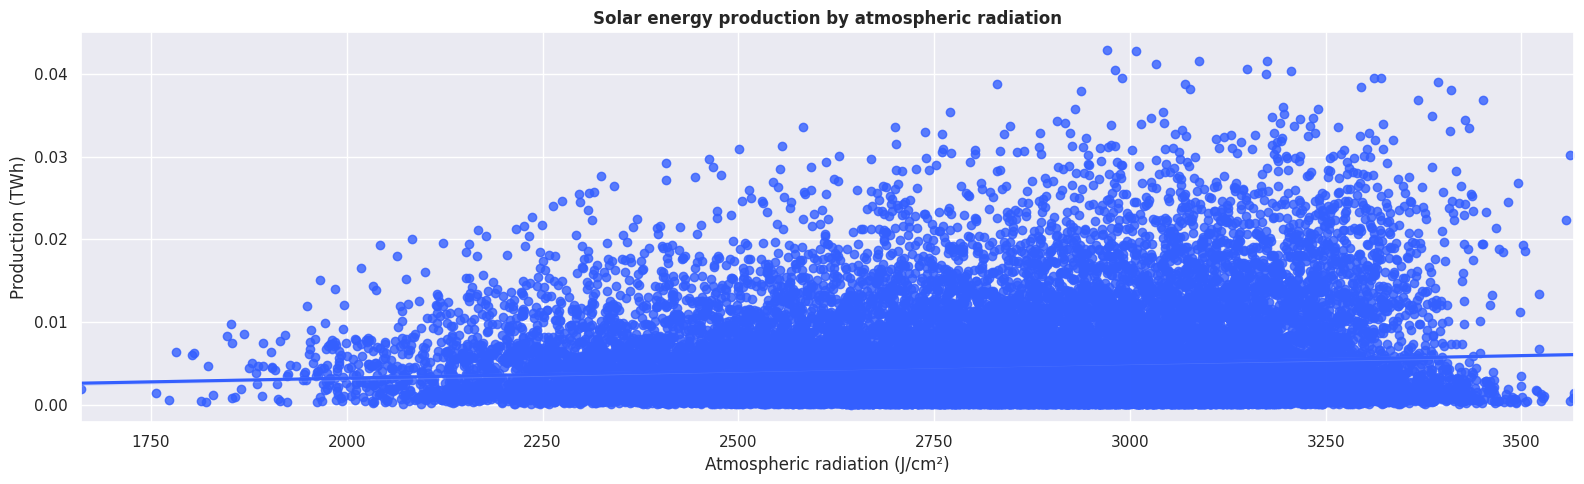

In [68]:
fig, ax = plt.subplots(figsize=(16, 5))

sns.regplot(data=solar_prod_df,
                x='atmospheric_radiation', 
                y='TWh', 
                ax=ax
                )

ax.set_xlabel("Atmospheric radiation (J/cm²)")
ax.set_ylabel("Production (TWh)")
ax.set_title("Solar energy production by atmospheric radiation", fontweight="bold")

ax.margins(x=0) # To start the graph at the Y axis and leave no space

plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; F. Correlation between meteorological variables and solar production

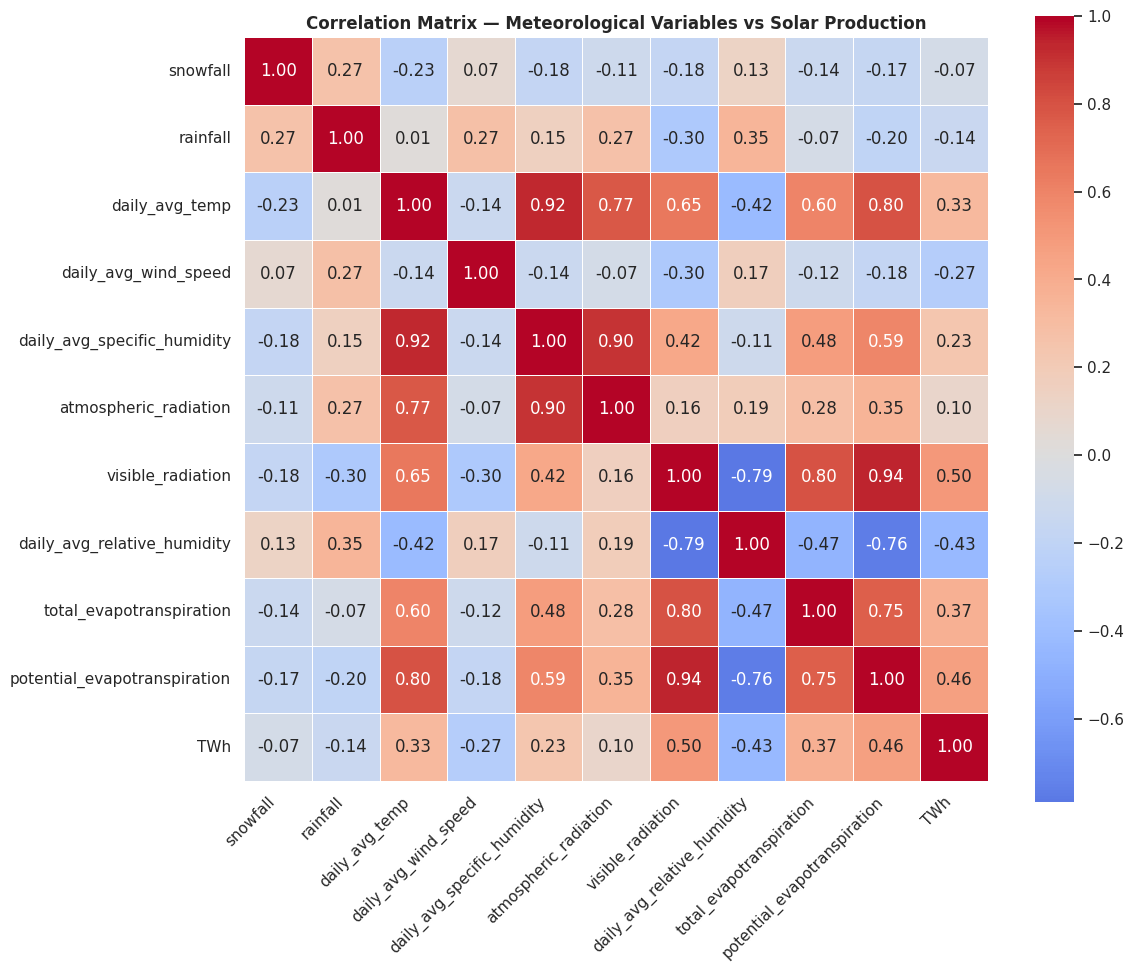

In [69]:
meteo_cols = ['snowfall', 'rainfall', 'daily_avg_temp', 'daily_avg_wind_speed', 
              'daily_avg_specific_humidity', 'atmospheric_radiation', 
              'visible_radiation', 'daily_avg_relative_humidity', 
              'total_evapotranspiration', 'potential_evapotranspiration', 'TWh'
              ]

corr = solar_prod_df[meteo_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=0.5, 
            ax=ax
            )

# Getting nice and clean x-axis, no legend colliding
ax.set_xticklabels(ax.get_xticklabels(),
                    rotation=45,
                    ha='right'
                    )
ax.set_title('Correlation Matrix — Meteorological Variables vs Solar Production', fontweight='bold')
plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; G. Top 4 correlations with TWh

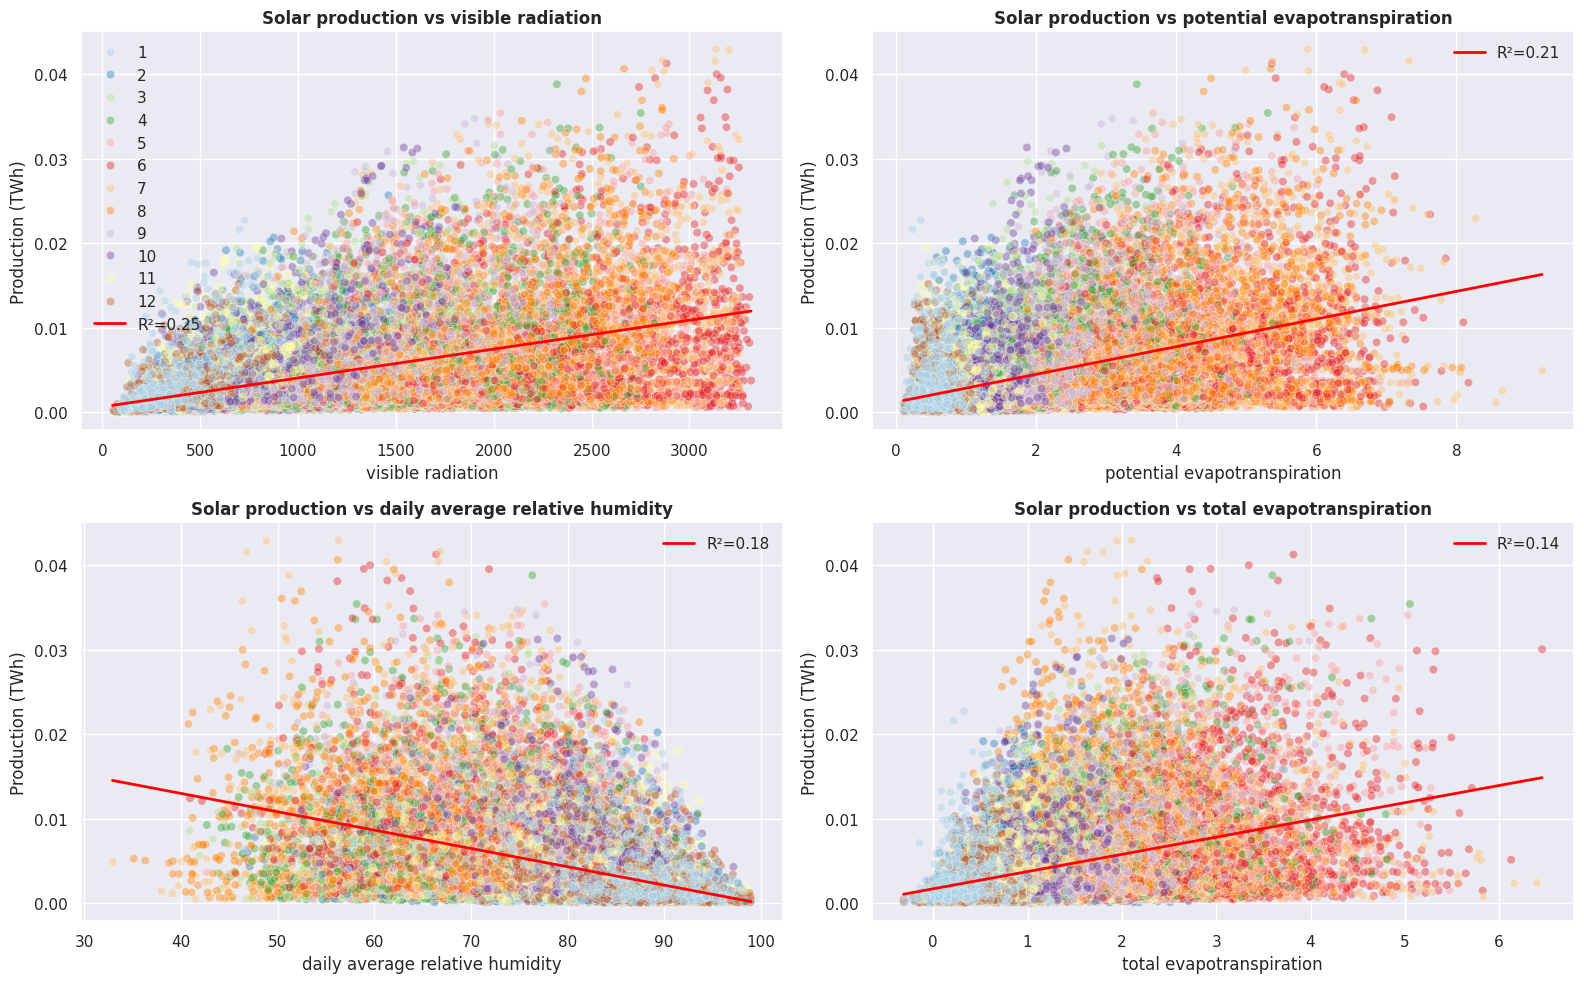

In [70]:
# Keep the top 4 correlated variables with TWh
top_corr = corr['TWh'].drop('TWh').abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_corr):
    sns.scatterplot(data=solar_prod_df, 
                    x=col,
                    y='TWh', 
                    hue=solar_prod_df['date'].dt.month, # Extract month for visualisation
                    palette='Paired',
                    alpha=0.4, 
                    ax=axes[i], 
                    legend=(i == 0)
                    )
    
    # Add regression line
    x_clean = solar_prod_df[[col, 'TWh']].dropna()
    slope, intercept, r, *_ = stats.linregress(x_clean[col], x_clean['TWh'])
    x_range = np.linspace(x_clean[col].min(), x_clean[col].max(), 100)
    axes[i].plot(x_range, slope * x_range + intercept, color='red', linewidth=2, label=f'R²={r**2:.2f}')
    axes[i].legend(frameon=False)
    axes[i].set_title(f'Solar production vs {col.replace("_", " ").replace("avg", "average")}', fontweight='bold')
    axes[i].set_xlabel(f'{col.replace("_", " ").replace("avg", "average")}')
    axes[i].set_ylabel('Production (TWh)')

plt.tight_layout()
plt.show()

### &nbsp;&nbsp;&nbsp; H. Solar production distribution

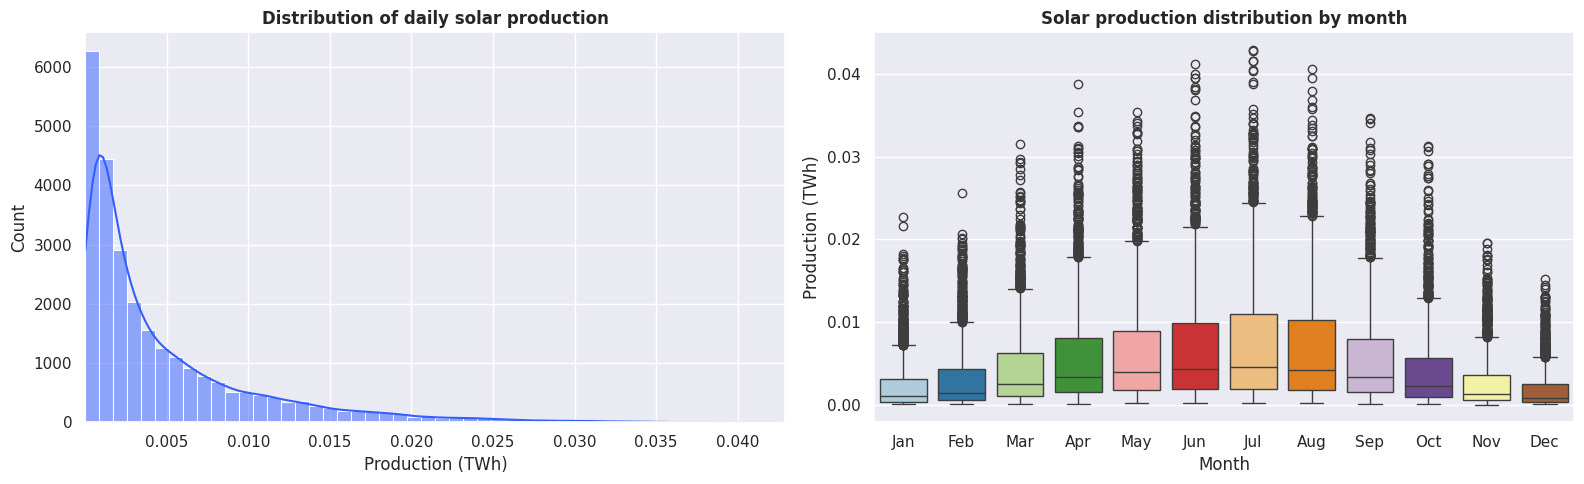

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
sns.histplot(data=solar_prod_df, 
             x='TWh', 
             bins=50, 
             kde=True, 
             ax=axes[0], 
             color=palette[0]
             )

axes[0].set_title('Distribution of daily solar production', fontweight='bold')
axes[0].set_xlabel('Production (TWh)')
axes[0].margins(x=0) # To start the graph at the Y axis and leave no space

# Boxplot per month
sns.boxplot(data=solar_prod_df, 
            x=solar_prod_df['date'].dt.month, # Extract month for visualisation
            y='TWh', 
            palette='Paired', 
            ax=axes[1]
            )

axes[1].set_title('Solar production distribution by month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Production (TWh)')
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()

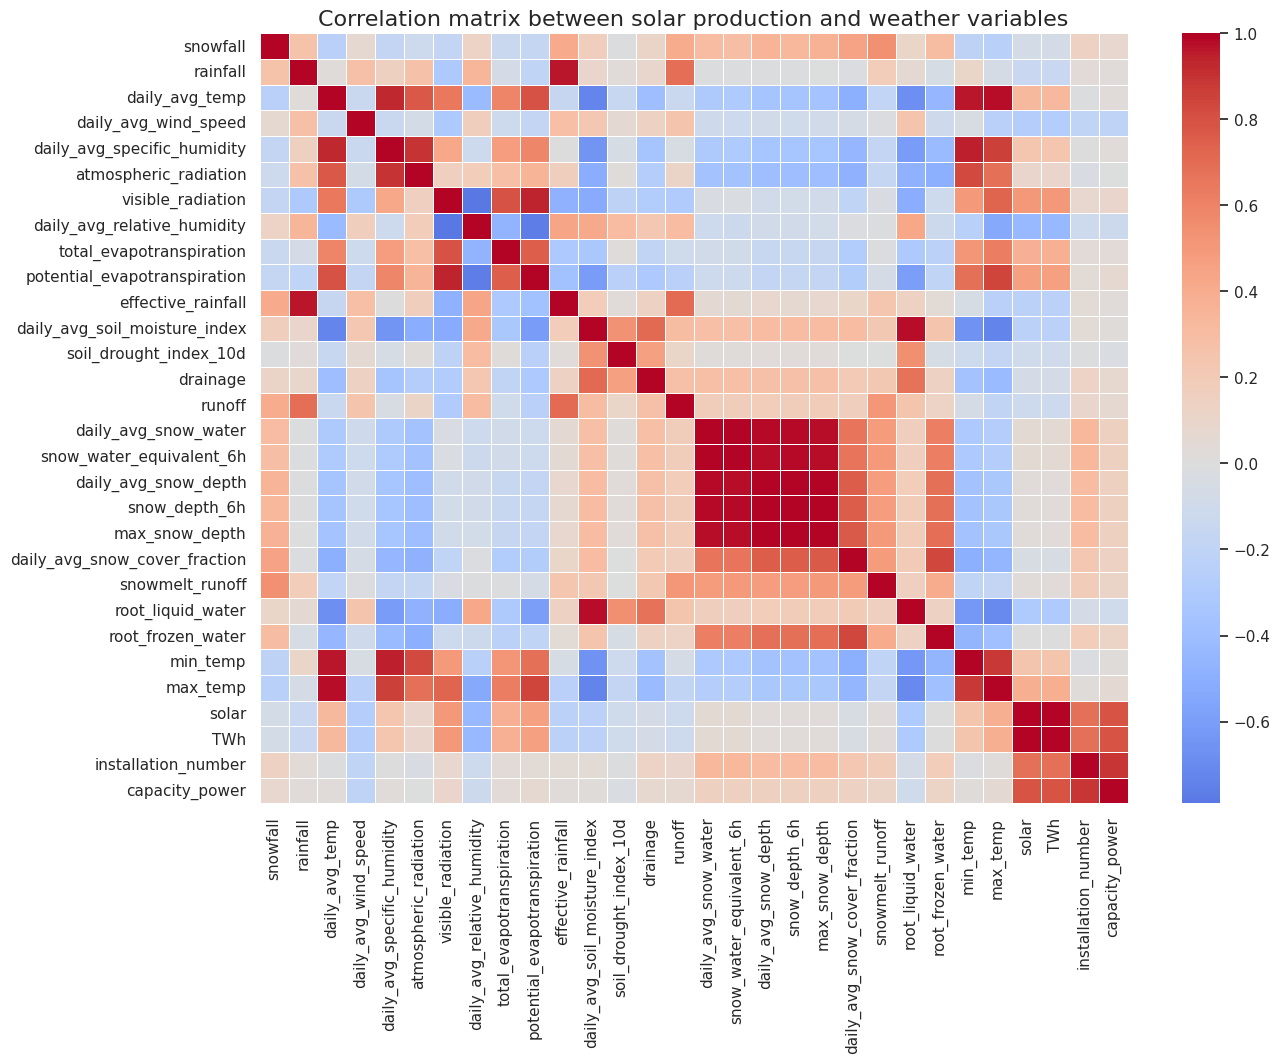

In [72]:
# Choose your final dataset here
# Replace final_df with your actual merged dataframe name if different
df = solar_prod_df.copy()

numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5,
)

plt.title("Correlation matrix between solar production and weather variables", fontsize=16)
plt.show()

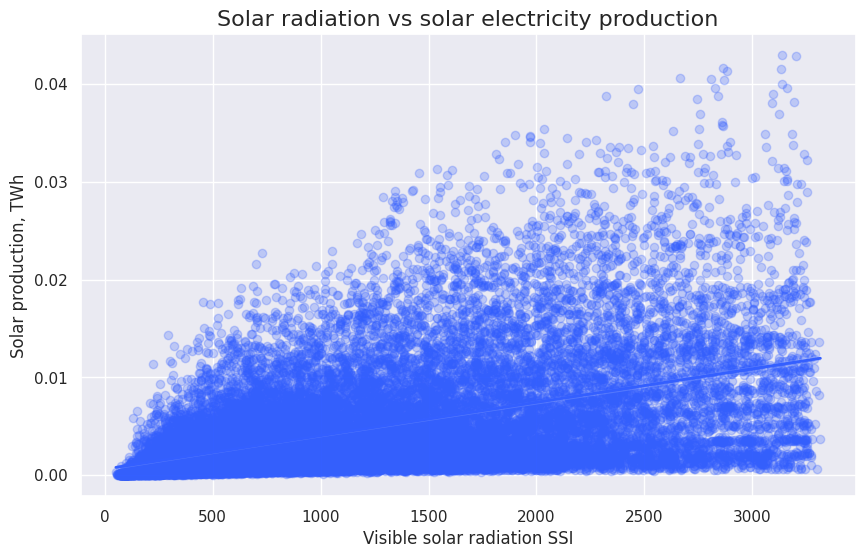

In [73]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="visible_radiation",
    y="TWh",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)

plt.title("Solar radiation vs solar electricity production", fontsize=16)
plt.xlabel("Visible solar radiation SSI")
plt.ylabel("Solar production, TWh")
plt.show()

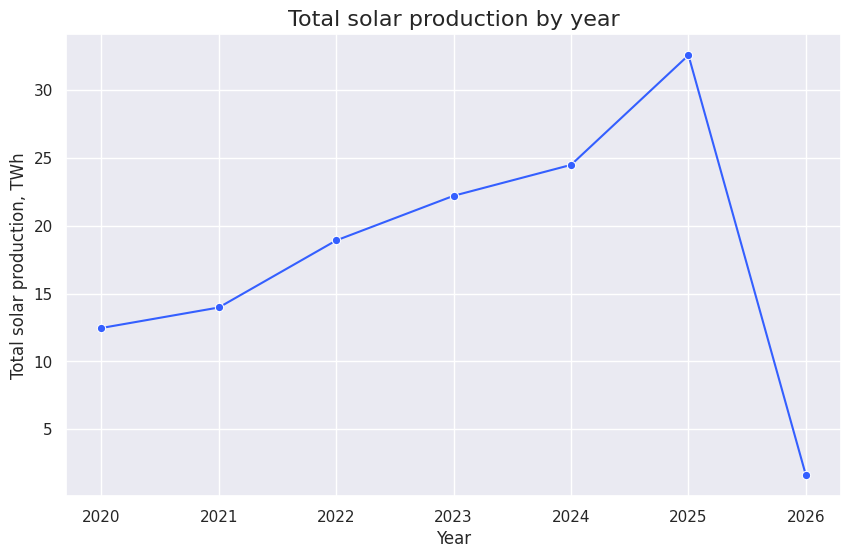

In [74]:
df["year"] = df["date"].dt.year

yearly = (
    df.groupby("year")["TWh"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly,
    x="year",
    y="TWh",
    marker="o"
)

plt.title("Total solar production by year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total solar production, TWh")
plt.show()

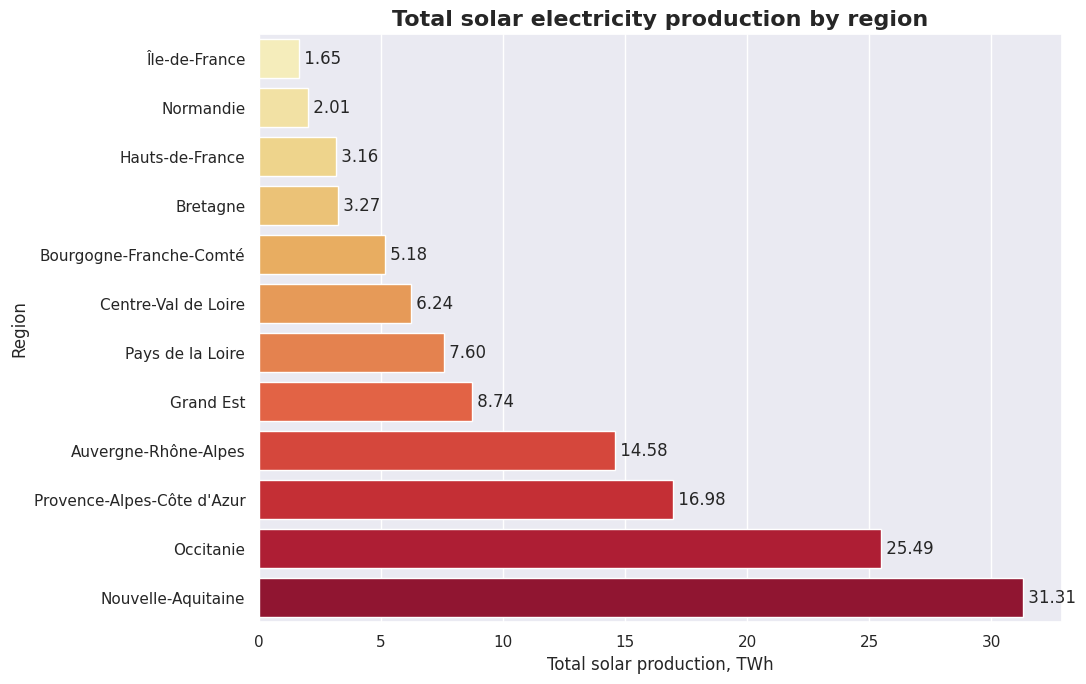

In [75]:
region_prod = (
    df.groupby("region", as_index=False)
    .agg(total_solar_TWh=("TWh", "sum"))
    .sort_values("total_solar_TWh", ascending=True)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=region_prod,
    x="total_solar_TWh",
    y="region",
    palette="YlOrRd"
)

plt.title("Total solar electricity production by region", fontsize=16, weight="bold")
plt.xlabel("Total solar production, TWh")
plt.ylabel("Region")

for index, value in enumerate(region_prod["total_solar_TWh"]):
    plt.text(value, index, f" {value:.2f}", va="center")

plt.tight_layout()
plt.show()

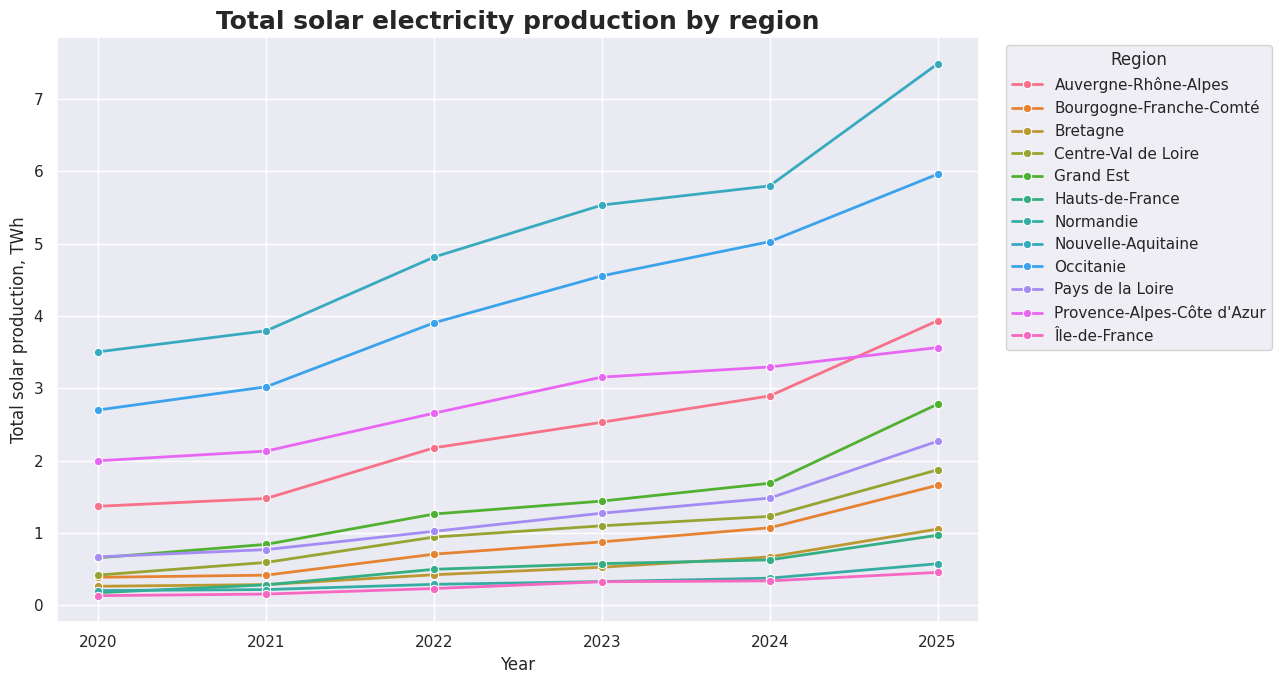

In [76]:
plot_df = df.copy()

plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["year"] = plot_df["date"].dt.year

# Remove incomplete year
plot_df = plot_df[plot_df["year"] < 2026]

year_region = (
    plot_df
    .groupby(["year", "region"], as_index=False)
    .agg(total_solar_TWh=("TWh", "sum"))
)

plt.figure(figsize=(13, 7))

sns.lineplot(
    data=year_region,
    x="year",
    y="total_solar_TWh",
    hue="region",
    marker="o",
    linewidth=2
)

plt.title(
    "Total solar electricity production by region",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Total solar production, TWh", fontsize=12)

plt.xticks(sorted(year_region["year"].unique()))

plt.legend(
    title="Region",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# 💹 4. Machine Learning

### &nbsp;&nbsp;&nbsp; A. Linear Regression Model

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 1: Only dataset data

In [77]:
# =========================
# 1. Préparation des données
# =========================

# Conversion de la date
solar_prod_df["date"] = pd.to_datetime(solar_prod_df["date"])

# Tri chronologique
solar_prod_df = solar_prod_df.sort_values(
    ["region", "date"]
).reset_index(drop=True) # Pour des données temporelles, on n'utilise pas de df.sample(random_state). En effet, il ne faut pas utiliser de données futures pour prédire le passé


# =========================
# 2. Création de la cible J+1
# =========================

solar_prod_df["target"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
solar_prod_df = solar_prod_df.dropna()

# =========================
# 3. Variables explicatives
# =========================

# Séparer X et y
print("Separating labels from features...")
X = solar_prod_df.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
Y = solar_prod_df["target"]
print("...Done.")
print()

print('Y : ')
print(Y.head())
print()
print('X :')
display(X.head())

# =========================
# 4. Découpage train / test
# =========================

train = solar_prod_df[solar_prod_df["date"] < "2024-01-01"]
test = solar_prod_df[solar_prod_df["date"] >= "2024-01-01"] # idem ici. On n'applique pas de randomisation avec des données temporelles. On se sert de l'existant pour prédire le future.

X_train = train.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
y_train = train["target"]

X_test = test.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"]) # à ajuster selon les colonnes que l'on souhaite supprimer
y_test = test["target"]


# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
    ])

# Preprocessings on train set
print("Performing preprocessings on train set...")
display(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(X_train[0:5,:])
print()

# Preprocessings on test set
print("Performing preprocessings on test set...")
display(X_test.head())
X_test = preprocessor.transform(X_test) # Don't fit again !!
print('...Done.')
display(X_test[0:5,:])
print()

Separating labels from features...
...Done.

Y : 
0    545.804788
1    475.324411
2    484.164050
3    684.262559
4    820.237755
Name: target, dtype: float64

X :


,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,...,snow_water_equivalent_6h,daily_avg_snow_depth,snow_depth_6h,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp
0,Auvergne-Rhône-Alpes,0.011617,0.021900,1.398744,1.008634,3.435516,2372.144741,638.449765,76.011146,0.285008,...,81.042622,0.252175,0.254006,0.254647,0.180455,0.126609,0.299488,0.005586,-0.994741,4.794584
1,Auvergne-Rhône-Alpes,0.004396,0.016641,1.982810,1.695133,3.737739,2352.648823,545.804788,77.651884,0.191052,...,80.928336,0.249118,0.250756,0.251330,0.180298,0.118603,0.298032,0.005600,-0.706044,4.893799
2,Auvergne-Rhône-Alpes,0.067111,0.893485,4.063344,1.916091,4.365964,2390.393485,475.324411,77.228807,0.163658,...,80.817033,0.246530,0.247735,0.248254,0.179906,0.053454,0.296637,0.005716,1.241994,6.404945
3,Auvergne-Rhône-Alpes,0.000628,0.163972,3.098901,2.696625,4.389766,2487.054239,484.164050,82.510283,0.385479,...,80.857143,0.244282,0.245624,0.246091,0.179435,0.081397,0.296600,0.004972,1.348666,5.375432
4,Auvergne-Rhône-Alpes,0.005495,0.000549,1.106672,2.062009,3.431376,2349.266327,684.262559,76.261146,0.400078,...,80.782261,0.241964,0.243148,0.243600,0.179121,0.065149,0.295068,0.005402,-0.770722,4.064050


Performing preprocessings on train set...


,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,...,snow_water_equivalent_6h,daily_avg_snow_depth,snow_depth_6h,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp
0,Auvergne-Rhône-Alpes,0.011617,0.021900,1.398744,1.008634,3.435516,2372.144741,638.449765,76.011146,0.285008,...,81.042622,0.252175,0.254006,0.254647,0.180455,0.126609,0.299488,0.005586,-0.994741,4.794584
1,Auvergne-Rhône-Alpes,0.004396,0.016641,1.982810,1.695133,3.737739,2352.648823,545.804788,77.651884,0.191052,...,80.928336,0.249118,0.250756,0.251330,0.180298,0.118603,0.298032,0.005600,-0.706044,4.893799
2,Auvergne-Rhône-Alpes,0.067111,0.893485,4.063344,1.916091,4.365964,2390.393485,475.324411,77.228807,0.163658,...,80.817033,0.246530,0.247735,0.248254,0.179906,0.053454,0.296637,0.005716,1.241994,6.404945
3,Auvergne-Rhône-Alpes,0.000628,0.163972,3.098901,2.696625,4.389766,2487.054239,484.164050,82.510283,0.385479,...,80.857143,0.244282,0.245624,0.246091,0.179435,0.081397,0.296600,0.004972,1.348666,5.375432
4,Auvergne-Rhône-Alpes,0.005495,0.000549,1.106672,2.062009,3.431376,2349.266327,684.262559,76.261146,0.400078,...,80.782261,0.241964,0.243148,0.243600,0.179121,0.065149,0.295068,0.005402,-0.770722,4.064050


...Done.
[[-0.20155251 -0.56120631 -1.62710854 -1.36438457 -1.46373197 -1.52144712
  -0.71456749 -0.10091516 -1.17978112 -1.18126062 -0.26204878  1.30388139
   1.43980921  2.33776701 -0.44537169  4.17776099  4.16952026  4.77113831
   4.77548061  4.70237454  2.41821141 -0.08164012  0.95579089  1.13516347
  -1.60277673 -1.47095782]
 [-0.21340832 -0.56253647 -1.53634896 -0.8909759  -1.34502231 -1.58615085
  -0.82700177  0.04315621 -1.27211353 -1.10101681 -0.24333718  1.26678436
   1.28962056  2.1277634  -0.44847756  4.17169653  4.16307869  4.70851701
   4.70931245  4.63594451  2.41574826 -0.09859516  0.91482772  1.13885153
  -1.55381846 -1.45755798]
 [-0.11044326 -0.34075779 -1.2130492  -0.73860392 -1.09826299 -1.46088255
  -0.91253702  0.00600629 -1.29903418 -1.06963191 -0.02157412  1.23575764
   1.12208576  1.95450141 -0.39676477  4.16978891  4.15680523  4.65550997
   4.64782608  4.57435603  2.4095904  -0.23656263  0.87556491  1.17095931
  -1.22346332 -1.25346482]
 [-0.21959395 -0.52527

,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,...,snow_water_equivalent_6h,daily_avg_snow_depth,snow_depth_6h,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp
1461,Auvergne-Rhône-Alpes,0.170173,1.218995,2.378885,2.340110,4.275163,2395.308163,422.007771,84.196625,0.258320,...,90.735871,0.259332,0.262538,0.263049,0.203454,0.514443,0.293798,0.003611,0.534694,4.992700
1462,Auvergne-Rhône-Alpes,4.070487,5.694819,5.080377,4.042151,5.034678,2771.111538,182.677237,83.495290,0.470251,...,90.445369,0.266747,0.258019,0.274863,0.180220,1.701413,0.293412,0.003945,1.873626,7.010832
1463,Auvergne-Rhône-Alpes,1.719231,2.813422,6.668289,4.429121,5.171710,2626.653689,531.675824,76.825353,0.737363,...,93.809655,0.271789,0.273323,0.274429,0.164129,0.629749,0.295980,0.003604,4.938697,9.059105
1464,Auvergne-Rhône-Alpes,0.400157,1.054003,5.063187,2.384458,4.600224,2359.786735,466.642151,75.543799,0.248823,...,95.086185,0.276441,0.278659,0.278806,0.161695,0.148666,0.296422,0.003504,2.987598,7.932182
1465,Auvergne-Rhône-Alpes,4.106986,5.611068,3.612009,1.739246,4.994378,2793.037991,171.388540,91.055965,0.469623,...,95.371743,0.289761,0.276764,0.296679,0.175510,0.648116,0.295677,0.003677,2.839482,4.588619


...Done.


array([[ 0.05875965, -0.2584271 , -1.47480174, -0.44620127, -1.13392843,
        -1.44457155, -0.97724229,  0.61784264, -1.20600754, -1.11502531,
         0.05525519,  1.10615249,  0.44932876,  1.62442712,  0.06166214,
         4.71487644,  4.71586842,  4.91773165,  4.94917003,  4.87063463,
         2.77906242,  0.73968194,  0.79571434,  0.58933112, -1.34340974,
        -1.44420054],
       [ 6.46218115,  0.87363484, -1.05500971,  0.72752312, -0.83559976,
        -0.19734226, -1.2676947 ,  0.55625924, -0.99773895, -0.87302481,
         1.93056093,  1.15209866,  0.3819935 ,  1.63583383,  1.48974271,
         4.81830949,  4.69949461,  5.06961443,  4.85716417,  5.10724251,
         2.41451669,  3.25334964,  0.78484972,  0.68153253, -1.11634881,
        -1.17163461],
       [ 2.60195795,  0.14484838, -0.80825976,  0.99437708, -0.78177541,
        -0.67677398, -0.84414874, -0.02942053, -0.73524339, -0.79815012,
         0.66723975,  1.16531143,  0.33732906,  1.67005398,  0.41247054,
       

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 1: Application

In [78]:
# =========================
# 1. Entraînement du modèle
# =========================

model = LinearRegression()

model.fit(X_train, y_train)

# =========================
# 6. Prédictions
# =========================

y_pred = model.predict(X_test)

# =========================
# 7. Evaluation
# =========================

print("R² :", round(r2_score(y_test, y_pred), 3))
print("MAE :", round(mean_absolute_error(y_test, y_pred), 3))
print("RMSE :", round(mean_squared_error(y_test, y_pred)**0.5, 3))

# =========================
# 8. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()
coefficients = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(solar_prod_df["visible_radiation"].describe())
print(coefficients)

R² : 0.759
MAE : 301.315
RMSE : 396.824
count    26664.000000
mean      1199.286422
std        819.418884
min         52.254064
25%        489.649570
50%       1037.395111
75%       1772.348928
max       3314.624151
Name: visible_radiation, dtype: float64
                              Variable   Coefficient
10             num__effective_rainfall  20516.330905
1                        num__rainfall -18704.990260
8        num__total_evapotranspiration   4890.460058
0                        num__snowfall  -2888.624157
15           num__daily_avg_snow_water   1459.103474
16       num__snow_water_equivalent_6h  -1302.136275
17           num__daily_avg_snow_depth  -1289.047116
19                 num__max_snow_depth   1068.712470
2                  num__daily_avg_temp   -528.541373
6               num__visible_radiation    422.097162
24                       num__min_temp    322.176532
9    num__potential_evapotranspiration    276.409741
5           num__atmospheric_radiation    107.469508
7 

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 2: Adding previous days' radiation to explanatory variables 

In [79]:
# =========================
# 1. Préparation des données
# =========================

# Tri chronologique

solar_prod_df["date"] = pd.to_datetime(solar_prod_df["date"])

solar_prod_df = solar_prod_df.sort_values(
    ["region", "date"]
).reset_index(drop=True) # Pour des données temporelles, on n'utilise pas de df.sample(random_state). En effet, il ne faut pas utiliser de données futures pour prédire le passé

# Ajout du rayonnement des jours précédents
solar_prod_df["radiation_J1"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

solar_prod_df["radiation_J2"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

solar_prod_df["radiation_J3"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)

# =========================
# 2. Création de la cible J+1
# =========================

solar_prod_df["target"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
solar_prod_df = solar_prod_df.dropna()

# =========================
# 3. Variables explicatives
# =========================

# Séparer X et y
print("Separating labels from features...")
X = solar_prod_df.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
Y = solar_prod_df["target"]
print("...Done.")
print()

print('Y : ')
print(Y.head())
print()
print('X :')
display(X.head())

# =========================
# 4. Découpage train / test
# =========================

train = solar_prod_df[solar_prod_df["date"] < "2024-01-01"]
test = solar_prod_df[solar_prod_df["date"] >= "2024-01-01"] # idem ici. On n'applique pas de randomisation avec des données temporelles. On se sert de l'existant pour prédire le future.

X_train = train.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
y_train = train["target"]

X_test = test.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"]) # à ajuster selon les colonnes que l'on souhaite supprimer
y_test = test["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# Preprocessings on train set
print("Performing preprocessings on train set...")
display(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(X_train[0:5,:])
print()

# Preprocessings on test set
print("Performing preprocessings on test set...")
display(X_test.head())
X_test = preprocessor.transform(X_test) # Don't fit again !!
print('...Done.')
display(X_test[0:5,:])
print()

Separating labels from features...
...Done.

Y : 
3    684.262559
4    820.237755
5    489.111538
6    480.869388
7    587.165149
Name: target, dtype: float64

X :


,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,...,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,radiation_J1,radiation_J2,radiation_J3
3,Auvergne-Rhône-Alpes,0.000628,0.163972,3.098901,2.696625,4.389766,2487.054239,484.164050,82.510283,0.385479,...,0.246091,0.179435,0.081397,0.296600,0.004972,1.348666,5.375432,475.324411,545.804788,638.449765
4,Auvergne-Rhône-Alpes,0.005495,0.000549,1.106672,2.062009,3.431376,2349.266327,684.262559,76.261146,0.400078,...,0.243600,0.179121,0.065149,0.295068,0.005402,-0.770722,4.064050,484.164050,475.324411,545.804788
5,Auvergne-Rhône-Alpes,0.001648,0.103454,2.484537,1.366013,3.520234,2252.122292,820.237755,70.817896,0.395604,...,0.241342,0.178336,0.117582,0.292845,0.006470,-1.472527,7.304474,684.262559,484.164050,475.324411
6,Auvergne-Rhône-Alpes,0.000078,0.568917,3.629749,1.848980,4.387305,2514.964992,489.111538,79.068210,0.206829,...,0.239000,0.177473,0.096468,0.292397,0.005847,0.557614,6.401256,820.237755,684.262559,484.164050
7,Auvergne-Rhône-Alpes,0.000000,0.115934,4.956201,1.154867,4.875305,2649.504396,480.869388,78.647331,0.264207,...,0.236957,0.176609,0.086342,0.292184,0.005388,2.656358,7.848195,489.111538,820.237755,684.262559


Performing preprocessings on train set...


,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,...,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,radiation_J1,radiation_J2,radiation_J3
3,Auvergne-Rhône-Alpes,0.000628,0.163972,3.098901,2.696625,4.389766,2487.054239,484.164050,82.510283,0.385479,...,0.246091,0.179435,0.081397,0.296600,0.004972,1.348666,5.375432,475.324411,545.804788,638.449765
4,Auvergne-Rhône-Alpes,0.005495,0.000549,1.106672,2.062009,3.431376,2349.266327,684.262559,76.261146,0.400078,...,0.243600,0.179121,0.065149,0.295068,0.005402,-0.770722,4.064050,484.164050,475.324411,545.804788
5,Auvergne-Rhône-Alpes,0.001648,0.103454,2.484537,1.366013,3.520234,2252.122292,820.237755,70.817896,0.395604,...,0.241342,0.178336,0.117582,0.292845,0.006470,-1.472527,7.304474,684.262559,484.164050,475.324411
6,Auvergne-Rhône-Alpes,0.000078,0.568917,3.629749,1.848980,4.387305,2514.964992,489.111538,79.068210,0.206829,...,0.239000,0.177473,0.096468,0.292397,0.005847,0.557614,6.401256,820.237755,684.262559,484.164050
7,Auvergne-Rhône-Alpes,0.000000,0.115934,4.956201,1.154867,4.875305,2649.504396,480.869388,78.647331,0.264207,...,0.236957,0.176609,0.086342,0.292184,0.005388,2.656358,7.848195,489.111538,820.237755,684.262559


...Done.
[[-0.21980235 -0.52549227 -1.36508738 -0.20071169 -1.09013064 -1.14007669
  -0.90446686  0.4720981  -1.08402152 -1.08025196 -0.25486634  1.21759478
   0.97504434  1.81632063 -0.32185227  4.17682583  4.16659257  4.62196867
   4.61731681  4.54280781  2.40326265 -0.17779999  0.87835226  0.96461397
  -1.20729016 -1.39489472 -0.91516698 -0.82939876 -0.71697573  1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [-0.21182041 -0.56679061 -1.67470637 -0.63821832 -1.46647155 -1.59719928
  -0.66153943 -0.07693835 -1.06966731 -1.10744548 -0.29461211  1.18478742
   0.84886742  1.68485451 -0.46304     4.17312904  4.16236538  4.57437732
   4.56679791  4.49281508  2.39833536 -0.21217651  0.83520076  1.08341898
  -1.56673625 -1.57204127 -0.90443554 -0.91495291 -0.82943604  1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [-0.2181

,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,...,max_snow_depth,daily_avg_snow_cover_fraction,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,radiation_J1,radiation_J2,radiation_J3
1461,Auvergne-Rhône-Alpes,0.170173,1.218995,2.378885,2.340110,4.275163,2395.308163,422.007771,84.196625,0.258320,...,0.263049,0.203454,0.514443,0.293798,0.003611,0.534694,4.992700,210.729906,676.892229,436.693093
1462,Auvergne-Rhône-Alpes,4.070487,5.694819,5.080377,4.042151,5.034678,2771.111538,182.677237,83.495290,0.470251,...,0.274863,0.180220,1.701413,0.293412,0.003945,1.873626,7.010832,422.007771,210.729906,676.892229
1463,Auvergne-Rhône-Alpes,1.719231,2.813422,6.668289,4.429121,5.171710,2626.653689,531.675824,76.825353,0.737363,...,0.274429,0.164129,0.629749,0.295980,0.003604,4.938697,9.059105,182.677237,422.007771,210.729906
1464,Auvergne-Rhône-Alpes,0.400157,1.054003,5.063187,2.384458,4.600224,2359.786735,466.642151,75.543799,0.248823,...,0.278806,0.161695,0.148666,0.296422,0.003504,2.987598,7.932182,531.675824,182.677237,422.007771
1465,Auvergne-Rhône-Alpes,4.106986,5.611068,3.612009,1.739246,4.994378,2793.037991,171.388540,91.055965,0.469623,...,0.296679,0.175510,0.648116,0.295677,0.003677,2.839482,4.588619,466.642151,531.675824,182.677237


...Done.


array([[ 0.05827808, -0.25887793, -1.47698743, -0.44649464, -1.13513291,
        -1.44445175, -0.97992702,  0.6202567 , -1.2090421 , -1.11755151,
         0.05510387,  1.10999313,  0.45258137,  1.63248477,  0.06106125,
         4.72332532,  4.7242589 ,  4.93098207,  4.96247586,  4.88319327,
         2.78020024,  0.73840891,  0.79945486,  0.58890396, -1.34533897,
        -1.4465956 , -1.23638806, -0.67027539, -0.96188504,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 6.45541531,  0.87220476, -1.05713964,  0.72689978, -0.83688637,
        -0.19769352, -1.27048367,  0.55863889, -1.00067447, -0.87549501,
         1.92857587,  1.15598164,  0.3851813 ,  1.64392184,  1.48783305,
         4.82692006,  4.70785969,  5.08323249,  4.87024764,  5.1203476 ,
         2.41558087,  3.2497214 ,  0.78857856,  0.68104288, -1.11825733,
        -1.17397844, -0.97989

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 2: Application

In [80]:
# =========================
# 1. Entraînement du modèle
# =========================

model = LinearRegression()

model.fit(X_train, y_train)

# =========================
# 6. Prédictions
# =========================

y_pred = model.predict(X_test)

# =========================
# 7. Evaluation
# =========================

print("R² :", round(r2_score(y_test, y_pred), 3))
print("MAE :", round(mean_absolute_error(y_test, y_pred), 3))
print("RMSE :", round(mean_squared_error(y_test, y_pred)**0.5, 3))

# =========================
# 8. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(solar_prod_df["visible_radiation"].describe())
print(coefficients)

R² : 0.771
MAE : 292.669
RMSE : 386.216
count    26616.000000
mean      1200.875240
std        819.256336
min         56.691844
25%        491.139837
50%       1039.140033
75%       1773.887405
max       3314.624151
Name: visible_radiation, dtype: float64
                                  Variable   Coefficient
10                 num__effective_rainfall  20855.919758
1                            num__rainfall -19049.803877
8            num__total_evapotranspiration   4988.532182
15               num__daily_avg_snow_water   3263.492445
16           num__snow_water_equivalent_6h  -3064.841028
0                            num__snowfall  -2937.426738
17               num__daily_avg_snow_depth  -2027.692916
19                     num__max_snow_depth   1054.899904
22                  num__root_liquid_water   -827.969766
18                      num__snow_depth_6h    817.745505
11      num__daily_avg_soil_moisture_index    797.131222
2                      num__daily_avg_temp   -441.048062
6  

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 3: Adding day of year data

In [81]:
# =========================
# 1. Préparation des données
# =========================

# Tri chronologique

solar_prod_df["date"] = pd.to_datetime(solar_prod_df["date"])

solar_prod_df = solar_prod_df.sort_values(
    ["region", "date"]
).reset_index(drop=True) # Pour des données temporelles, on n'utilise pas de df.sample(random_state). En effet, il ne faut pas utiliser de données futures pour prédire le passé

# Ajout du rayonnement des jours précédents
solar_prod_df["radiation_J1"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

solar_prod_df["radiation_J2"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

solar_prod_df["radiation_J3"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)

# Ajout des données sur le jour de l'année - Modèle 3

solar_prod_df["day_sin"] = np.sin(
    2*np.pi*solar_prod_df["date"].dt.dayofyear/365
)

solar_prod_df["day_cos"] = np.cos(
    2*np.pi*solar_prod_df["date"].dt.dayofyear/365
)

# =========================
# 2. Création de la cible J+1
# =========================


solar_prod_df["target"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
solar_prod_df = solar_prod_df.dropna()

# =========================
# 3. Variables explicatives
# =========================

# Séparer X et y
print("Separating labels from features...")
X = solar_prod_df.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
Y = solar_prod_df["target"]
print("...Done.")
print()

print('Y : ')
print(Y.head())
print()
print('X :')
display(X.head())

# =========================
# 4. Découpage train / test
# =========================

train = solar_prod_df[solar_prod_df["date"] < "2024-01-01"]
test = solar_prod_df[solar_prod_df["date"] >= "2024-01-01"] # idem ici. On n'applique pas de randomisation avec des données temporelles. On se sert de l'existant pour prédire le future.

X_train = train.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
y_train = train["target"]

X_test = test.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"]) # à ajuster selon les colonnes que l'on souhaite supprimer
y_test = test["target"]


# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# Preprocessings on train set
print("Performing preprocessings on train set...")
display(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(X_train[0:5,:])
print()

# Preprocessings on test set
print("Performing preprocessings on test set...")
display(X_test.head())
X_test = preprocessor.transform(X_test) # Don't fit again !!
print('...Done.')
display(X_test[0:5,:])
print()

Separating labels from features...
...Done.

Y : 
3    480.869388
4    587.165149
5    388.333281
6    603.618210
7    799.018132
Name: target, dtype: float64

X :


,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,...,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,radiation_J1,radiation_J2,radiation_J3,day_sin,day_cos
3,Auvergne-Rhône-Alpes,0.000078,0.568917,3.629749,1.848980,4.387305,2514.964992,489.111538,79.068210,0.206829,...,0.096468,0.292397,0.005847,0.557614,6.401256,820.237755,684.262559,484.164050,0.120208,0.992749
4,Auvergne-Rhône-Alpes,0.000000,0.115934,4.956201,1.154867,4.875305,2649.504396,480.869388,78.647331,0.264207,...,0.086342,0.292184,0.005388,2.656358,7.848195,489.111538,820.237755,684.262559,0.137279,0.990532
5,Auvergne-Rhône-Alpes,0.249372,1.986185,6.234929,2.961068,4.231785,2523.524411,587.165149,64.313736,0.651099,...,0.236107,0.291268,0.005496,2.857535,9.961146,480.869388,489.111538,820.237755,0.154309,0.988023
6,Auvergne-Rhône-Alpes,0.200314,0.829513,3.791287,2.344035,4.627595,2629.219702,388.333281,82.875039,0.517111,...,0.128336,0.291560,0.005133,2.469388,5.781554,587.165149,480.869388,489.111538,0.171293,0.985220
7,Auvergne-Rhône-Alpes,0.008556,0.008399,1.659184,1.709969,3.706005,2389.158713,603.618210,77.917661,0.368446,...,0.081554,0.290786,0.005418,0.162323,4.105495,388.333281,587.165149,480.869388,0.188227,0.982126


Performing preprocessings on train set...


,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,...,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,radiation_J1,radiation_J2,radiation_J3,day_sin,day_cos
3,Auvergne-Rhône-Alpes,0.000078,0.568917,3.629749,1.848980,4.387305,2514.964992,489.111538,79.068210,0.206829,...,0.096468,0.292397,0.005847,0.557614,6.401256,820.237755,684.262559,484.164050,0.120208,0.992749
4,Auvergne-Rhône-Alpes,0.000000,0.115934,4.956201,1.154867,4.875305,2649.504396,480.869388,78.647331,0.264207,...,0.086342,0.292184,0.005388,2.656358,7.848195,489.111538,820.237755,684.262559,0.137279,0.990532
5,Auvergne-Rhône-Alpes,0.249372,1.986185,6.234929,2.961068,4.231785,2523.524411,587.165149,64.313736,0.651099,...,0.236107,0.291268,0.005496,2.857535,9.961146,480.869388,489.111538,820.237755,0.154309,0.988023
6,Auvergne-Rhône-Alpes,0.200314,0.829513,3.791287,2.344035,4.627595,2629.219702,388.333281,82.875039,0.517111,...,0.128336,0.291560,0.005133,2.469388,5.781554,587.165149,480.869388,489.111538,0.171293,0.985220
7,Auvergne-Rhône-Alpes,0.008556,0.008399,1.659184,1.709969,3.706005,2389.158713,603.618210,77.917661,0.368446,...,0.081554,0.290786,0.005418,0.162323,4.105495,388.333281,587.165149,480.869388,0.188227,0.982126


...Done.
[[-0.22092801 -0.42388491 -1.285503   -0.78596119 -1.09338749 -1.04882453
  -0.9001584   0.17081023 -1.2617667  -1.07720082 -0.12152911  1.13180075
   0.59142089  1.46381504 -0.40932028  4.16914155  4.15994925  4.49490664
   4.48668836  4.41108606  2.37346961 -0.14638903  0.76337337  1.20544669
  -1.34444659 -1.25891529 -0.49855175 -0.6637094  -0.90693533  0.17004531
   1.41122322  1.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.22105662 -0.53827116 -1.07926988 -1.26429645 -0.90173361 -0.60253841
  -0.91016318  0.13384266 -1.20535149 -1.13672921 -0.23851173  1.11362002
   0.48390474  1.36401677 -0.3488607   4.16377903  4.15415778  4.45236122
   4.44525511  4.36998681  2.35991708 -0.16779206  0.75737743  1.07870685
  -0.98833753 -1.06340615 -0.90057488 -0.49861482 -0.66395006  0.19414603
   1.40808356  1.          0.          0.          0.          0.
   0.          0.          0.         

,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,total_evapotranspiration,...,snowmelt_runoff,root_liquid_water,root_frozen_water,min_temp,max_temp,radiation_J1,radiation_J2,radiation_J3,day_sin,day_cos
1458,Auvergne-Rhône-Alpes,0.170173,1.218995,2.378885,2.340110,4.275163,2395.308163,422.007771,84.196625,0.258320,...,0.514443,0.293798,0.003611,0.534694,4.992700,210.729906,676.892229,436.693093,0.017213,0.999852
1459,Auvergne-Rhône-Alpes,4.070487,5.694819,5.080377,4.042151,5.034678,2771.111538,182.677237,83.495290,0.470251,...,1.701413,0.293412,0.003945,1.873626,7.010832,422.007771,210.729906,676.892229,0.034422,0.999407
1460,Auvergne-Rhône-Alpes,1.719231,2.813422,6.668289,4.429121,5.171710,2626.653689,531.675824,76.825353,0.737363,...,0.629749,0.295980,0.003604,4.938697,9.059105,182.677237,422.007771,210.729906,0.051620,0.998667
1461,Auvergne-Rhône-Alpes,0.400157,1.054003,5.063187,2.384458,4.600224,2359.786735,466.642151,75.543799,0.248823,...,0.148666,0.296422,0.003504,2.987598,7.932182,531.675824,182.677237,422.007771,0.068802,0.997630
1462,Auvergne-Rhône-Alpes,4.106986,5.611068,3.612009,1.739246,4.994378,2793.037991,171.388540,91.055965,0.469623,...,0.648116,0.295677,0.003677,2.839482,4.588619,466.642151,531.675824,182.677237,0.085965,0.996298


...Done.


array([[ 0.05777969, -0.25972845, -1.4799838 , -0.44750775, -1.13742943,
        -1.44574305, -0.98161269,  0.6212603 , -1.21113964, -1.12012572,
         0.05452055,  1.11340399,  0.45466085,  1.63725672,  0.06009405,
         4.73179602,  4.73266946,  4.94332963,  4.97484953,  4.89483506,
         2.78127765,  0.73710835,  0.80286691,  0.58842951, -1.34833558,
        -1.44923815, -1.23856037, -0.67265811, -0.96458066,  0.02463579,
         1.42128578,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 6.44863579,  0.87049726, -1.05996337,  0.72542247, -0.83914258,
        -0.19915042, -1.27212538,  0.55965917, -1.00276609, -0.87800776,
         1.92620647,  1.15942407,  0.38725635,  1.648707  ,  1.48569979,
         4.83555286,  4.71624478,  5.09592137,  4.88241532,  5.13249384,
         2.41659131,  3.24607499,  0.7919813 ,  0.68050545, -1.12114924,
   

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 3: Application

In [82]:
# =========================
# 1. Entraînement du modèle
# =========================

model = LinearRegression()

model.fit(X_train, y_train)

# =========================
# 6. Prédictions
# =========================

y_pred = model.predict(X_test)

# =========================
# 7. Evaluation
# =========================

print("R² :", round(r2_score(y_test, y_pred), 3))
print("MAE :", round(mean_absolute_error(y_test, y_pred), 3))
print("RMSE :", round(mean_squared_error(y_test, y_pred)**0.5, 3))

# =========================
# 8. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(solar_prod_df["visible_radiation"].describe())
print(coefficients)

R² : 0.792
MAE : 279.455
RMSE : 368.825
count    26568.000000
mean      1202.186374
std        819.362036
min         56.691844
25%        492.162946
50%       1041.445543
75%       1775.926951
max       3314.624151
Name: visible_radiation, dtype: float64
                                  Variable   Coefficient
10                 num__effective_rainfall  16167.613767
1                            num__rainfall -14798.017966
8            num__total_evapotranspiration   3803.621440
0                            num__snowfall  -2294.899422
15               num__daily_avg_snow_water    892.325666
16           num__snow_water_equivalent_6h   -865.547650
19                     num__max_snow_depth    743.015152
2                      num__daily_avg_temp   -733.008717
22                  num__root_liquid_water   -611.655053
11      num__daily_avg_soil_moisture_index    582.180729
17               num__daily_avg_snow_depth   -415.126667
6                   num__visible_radiation    374.703962
18 

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 4 - Using TimeSeriesSplit

In [83]:
# 1. Préparation des données
# =========================

# Tri chronologique

solar_prod_df["date"] = pd.to_datetime(solar_prod_df["date"])

solar_prod_df = solar_prod_df.sort_values(
    ["region", "date"]
).reset_index(drop=True) # Pour des données temporelles, on n'utilise pas de df.sample(random_state). En effet, il ne faut pas utiliser de données futures pour prédire le passé

# Ajout du rayonnement des jours précédents
solar_prod_df["radiation_J1"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

solar_prod_df["radiation_J2"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

solar_prod_df["radiation_J3"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)

# Ajout des données sur le jour de l'année - Modèle 3

solar_prod_df["day_sin"] = np.sin(
    2*np.pi*solar_prod_df["date"].dt.dayofyear/365
)

solar_prod_df["day_cos"] = np.cos(
    2*np.pi*solar_prod_df["date"].dt.dayofyear/365
)

# =========================
# 2. Création de la cible J+1
# =========================


solar_prod_df["target"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
solar_prod_df = solar_prod_df.dropna()

# =========================
# 3. Tri par date
# =========================

solar_prod_df = solar_prod_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

solar_prod_df = solar_prod_df.sort_values(["date", "region"]).reset_index(drop=True)

# =========================
# 4. Séparation X / y
# =========================

X = solar_prod_df.drop(columns=["date", "solar", "target", "TWh", "installation_number", "capacity_power"])
y = solar_prod_df["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]
)

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =========================
# 5. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

model_r2_scores = []
model_mae_scores = []
model_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)

    y_pred_model = model.predict(X_test_scaled)

    model_r2 = r2_score(y_test, y_pred_model)
    model_mae = mean_absolute_error(y_test, y_pred_model)
    model_rmse = np.sqrt(mean_squared_error(y_test, y_pred_model))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    model_r2_scores.append(model_r2)
    model_mae_scores.append(model_mae)
    model_rmse_scores.append(model_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Modèle R²": model_r2,
        "Modèle MAE": model_mae,
        "Modèle RMSE": model_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Régression linéaire"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(model_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(model_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(model_rmse_scores)
    ]
})

display(results)

,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Modèle R²,Modèle MAE,Modèle RMSE
0,1,2020-01-10,2021-01-12,2021-01-12,2022-01-15,0.659744,320.640187,442.553954,0.741246,294.077972,385.928609
1,2,2020-01-10,2022-01-15,2022-01-15,2023-01-18,0.739069,324.122303,450.120281,0.808323,296.200522,385.789528
2,3,2020-01-10,2023-01-18,2023-01-19,2024-01-22,0.718092,309.174726,420.773805,0.794667,273.851877,359.107876
3,4,2020-01-10,2024-01-22,2024-01-22,2025-01-24,0.649814,321.877266,439.159740,0.754814,278.692680,367.468850
4,5,2020-01-10,2025-01-24,2025-01-24,2026-01-27,0.735031,319.860955,444.083991,0.807763,287.563850,378.256540


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.700350,319.135088,439.338354
1,Régression linéaire,0.781363,286.077380,375.310281


#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 4: Application

In [84]:

# =========================
# 7. Coefficients du dernier modèle
# =========================

feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)


print("===== Coefficients du dernier fold =====")
display(coefficients)

# =========================
# 8. Statistiques de la cible
# =========================

print()
print("===== Statistiques visible_radiation =====")
print(solar_prod_df["visible_radiation"].describe())

===== Coefficients du dernier fold =====


,Variable,Coefficient
1,num__rainfall,-1251.287211
10,num__effective_rainfall,1238.880663
15,num__daily_avg_snow_water,932.420436
16,num__snow_water_equivalent_6h,-930.470858
2,num__daily_avg_temp,-717.481725
19,num__max_snow_depth,612.306615
22,num__root_liquid_water,-609.417364
11,num__daily_avg_soil_moisture_index,580.022686
18,num__snow_depth_6h,-401.637896
6,num__visible_radiation,349.862162



===== Statistiques visible_radiation =====
count    26520.000000
mean      1203.783364
std        819.184187
min         56.691844
25%        493.287735
50%       1043.777292
75%       1776.836147
max       3314.624151
Name: visible_radiation, dtype: float64


### &nbsp;&nbsp;&nbsp; B. Random Forest Model

#### &nbsp;&nbsp;&nbsp;&nbsp; - Model 1: No data modification

In [85]:
# =========================
# 1. Préparation des données
# =========================

# Tri chronologique

solar_prod_df["date"] = pd.to_datetime(solar_prod_df["date"])

solar_prod_df = solar_prod_df.sort_values(
    ["region", "date"]
).reset_index(drop=True) # Pour des données temporelles, on n'utilise pas de df.sample(random_state). En effet, il ne faut pas utiliser de données futures pour prédire le passé

# Ajout du rayonnement des jours précédents
solar_prod_df["radiation_J1"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

solar_prod_df["radiation_J2"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

solar_prod_df["radiation_J3"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)

# Ajout des données sur le jour de l'année - Modèle 3

solar_prod_df["day_sin"] = np.sin(
    2*np.pi*solar_prod_df["date"].dt.dayofyear/365
)

solar_prod_df["day_cos"] = np.cos(
    2*np.pi*solar_prod_df["date"].dt.dayofyear/365
)

# =========================
# 2. Création de la cible J+1
# =========================


solar_prod_df["target"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# Suppression de la dernière ligne
solar_prod_df = solar_prod_df.dropna()

# =========================
# 3. Tri par date
# =========================

solar_prod_df = solar_prod_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

solar_prod_df = solar_prod_df.sort_values(["date", "region"]).reset_index(drop=True)

# =========================
# 4. Séparation X / y
# =========================

X = solar_prod_df.drop(columns=["date", "solar", "target", "installation_number", "capacity_power"])
y = solar_prod_df["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =========================
# 5. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

model_r2_scores = []
model_mae_scores = []
model_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        random_state=42,
        n_jobs=-1
        )

    model.fit(X_train_scaled, y_train)

    y_pred_model = model.predict(X_test_scaled)

    model_r2 = r2_score(y_test, y_pred_model)
    model_mae = mean_absolute_error(y_test, y_pred_model)
    model_rmse = np.sqrt(mean_squared_error(y_test, y_pred_model))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    model_r2_scores.append(model_r2)
    model_mae_scores.append(model_mae)
    model_rmse_scores.append(model_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Modèle R²": model_r2,
        "Modèle MAE": model_mae,
        "Modèle RMSE": model_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Random Forest"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(model_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(model_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(model_rmse_scores)
    ]
})

display(results)

,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Modèle R²,Modèle MAE,Modèle RMSE
0,1,2020-01-13,2021-01-14,2021-01-14,2022-01-17,0.659209,320.626270,442.706557,0.735061,301.339262,390.342010
1,2,2020-01-13,2022-01-17,2022-01-17,2023-01-19,0.738323,324.811360,450.632006,0.794282,307.144763,399.554170
2,3,2020-01-13,2023-01-19,2023-01-20,2024-01-22,0.718072,309.314728,420.971753,0.783665,281.366562,368.763253
3,4,2020-01-13,2024-01-22,2024-01-22,2025-01-24,0.649007,322.262995,439.525652,0.761770,276.657092,362.103822
4,5,2020-01-13,2025-01-24,2025-01-24,2026-01-26,0.734853,319.970694,444.318795,0.819842,279.656674,366.249826


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.699893,319.397210,439.630953
1,Random Forest,0.778924,289.232871,377.402616


Test 2 - Créer des moyennes glissantes sur 7 et 30j pour le rayonnement et sur 7j pour les variables explicatives les plus importantes

In [86]:
# =========================
# 1. Préparation des données
# =========================

solar_prod_df["date"] = pd.to_datetime(solar_prod_df["date"])

solar_prod_df = solar_prod_df.sort_values(
    ["region", "date"]
).reset_index(drop=True)

# =========================
# 3. Lags J-1, J-2, J-3
# =========================

solar_prod_df["radiation_J1"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

solar_prod_df["radiation_J2"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

solar_prod_df["radiation_J3"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)

# =========================
# 4. Moyennes glissantes par région
# =========================

solar_prod_df["radiation_7d_mean"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["radiation_30d_mean"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=30).mean())
)

solar_prod_df["temp_7d_mean"] = (
    solar_prod_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["humidity_7d_mean"] = (
    solar_prod_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["rainfall_7d_sum"] = (
    solar_prod_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)

# =========================
# 4. Variables saisonnières
# =========================

solar_prod_df["day_sin"] = np.sin(
    2 * np.pi * solar_prod_df["date"].dt.dayofyear / 365
)

solar_prod_df["day_cos"] = np.cos(
    2 * np.pi * solar_prod_df["date"].dt.dayofyear / 365
)

# =========================
# 2. Cible J+1 par région
# =========================

solar_prod_df["target"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# =========================
# 3. Tri par date
# =========================

solar_prod_df = solar_prod_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

solar_prod_df = solar_prod_df.sort_values(["date", "region"]).reset_index(drop=True)

# =========================
# 6. Séparation X / y
# =========================

X = solar_prod_df.drop(
    columns=[
        "date",
        "solar",
        "target",
        "TWh",
        "installation_number",
        "capacity_power"
    ],
    errors="ignore"
)
y = solar_prod_df["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# =========================
# 5. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

model_r2_scores = []
model_mae_scores = []
model_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        random_state=42,
        n_jobs=-1
        )

    model.fit(X_train_scaled, y_train)

    y_pred_model = model.predict(X_test_scaled)

    model_r2 = r2_score(y_test, y_pred_model)
    model_mae = mean_absolute_error(y_test, y_pred_model)
    model_rmse = np.sqrt(mean_squared_error(y_test, y_pred_model))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    model_r2_scores.append(model_r2)
    model_mae_scores.append(model_mae)
    model_rmse_scores.append(model_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Modèle R²": model_r2,
        "Modèle MAE": model_mae,
        "Modèle RMSE": model_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Random Forest"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(model_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(model_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(model_rmse_scores)
    ]
})

display(results)

# =========================
# 9. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()

importances = pd.DataFrame({
    "Variable": feature_names,
    "Importance": model.feature_importances_
})

importances = importances.sort_values(
    by="Importance",
    ascending=False
)

print()
print("===== Importance des variables Random Forest =====")
print(importances)

# =========================
# 10. Statistiques de la cible
# =========================

print()
print("===== Statistiques visible_radiation =====")
print(solar_prod_df["visible_radiation"].describe())

,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Modèle R²,Modèle MAE,Modèle RMSE
0,1,2020-02-12,2021-02-08,2021-02-08,2022-02-05,0.649381,321.780709,444.545461,0.733810,296.299645,387.341972
1,2,2020-02-12,2022-02-05,2022-02-06,2023-02-03,0.735421,327.398407,453.033656,0.791437,308.689040,402.226966
2,3,2020-02-12,2023-02-03,2023-02-03,2024-01-31,0.713914,312.562956,423.953740,0.777632,286.052135,373.771702
3,4,2020-02-12,2024-01-31,2024-02-01,2025-01-28,0.649104,323.730863,441.501388,0.765771,275.523839,360.714114
4,5,2020-02-12,2025-01-28,2025-01-28,2026-01-25,0.731286,322.218199,446.735714,0.813630,284.079052,372.042915


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.695821,321.538227,441.953992
1,Random Forest,0.776456,290.128742,379.219534



===== Importance des variables Random Forest =====
                                  Variable  Importance
9        num__potential_evapotranspiration    0.549555
6                   num__visible_radiation    0.149861
31                  num__radiation_7d_mean    0.088806
30                            num__day_cos    0.021793
1                            num__rainfall    0.019888
10                 num__effective_rainfall    0.014410
32                 num__radiation_30d_mean    0.012838
29                            num__day_sin    0.012603
27                       num__radiation_J2    0.008183
3                num__daily_avg_wind_speed    0.007936
28                       num__radiation_J3    0.007843
26                       num__radiation_J1    0.007760
8            num__total_evapotranspiration    0.007626
35                    num__rainfall_7d_sum    0.007613
14                             num__runoff    0.007186
12             num__soil_drought_index_10d    0.006757
34           

In [87]:
print(solar_prod_df.columns.tolist())

['date', 'region', 'snowfall', 'rainfall', 'daily_avg_temp', 'daily_avg_wind_speed', 'daily_avg_specific_humidity', 'atmospheric_radiation', 'visible_radiation', 'daily_avg_relative_humidity', 'total_evapotranspiration', 'potential_evapotranspiration', 'effective_rainfall', 'daily_avg_soil_moisture_index', 'soil_drought_index_10d', 'drainage', 'runoff', 'daily_avg_snow_water', 'snow_water_equivalent_6h', 'daily_avg_snow_depth', 'snow_depth_6h', 'max_snow_depth', 'daily_avg_snow_cover_fraction', 'snowmelt_runoff', 'root_liquid_water', 'root_frozen_water', 'min_temp', 'max_temp', 'solar', 'TWh', 'installation_number', 'capacity_power', 'target', 'radiation_J1', 'radiation_J2', 'radiation_J3', 'day_sin', 'day_cos', 'radiation_7d_mean', 'radiation_30d_mean', 'temp_7d_mean', 'humidity_7d_mean', 'rainfall_7d_sum']


Test 3 - Changement des paramètres de l'arbre

In [88]:
# =========================
# 1. Préparation des données
# =========================

solar_prod_df["date"] = pd.to_datetime(solar_prod_df["date"])

solar_prod_df = solar_prod_df.sort_values(
    ["region", "date"]
).reset_index(drop=True)

# =========================
# 3. Lags J-1, J-2, J-3
# =========================

solar_prod_df["radiation_J1"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

solar_prod_df["radiation_J2"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

solar_prod_df["radiation_J3"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)

# =========================
# 4. Moyennes glissantes par région
# =========================

solar_prod_df["radiation_7d_mean"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["radiation_30d_mean"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=30).mean())
)

solar_prod_df["temp_7d_mean"] = (
    solar_prod_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["humidity_7d_mean"] = (
    solar_prod_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["rainfall_7d_sum"] = (
    solar_prod_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)

# =========================
# 4. Variables saisonnières
# =========================

solar_prod_df["day_sin"] = np.sin(
    2 * np.pi * solar_prod_df["date"].dt.dayofyear / 365
)

solar_prod_df["day_cos"] = np.cos(
    2 * np.pi * solar_prod_df["date"].dt.dayofyear / 365
)

# =========================
# 5. Cible J+1 par région
# =========================

solar_prod_df["target"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# =========================
# 6. Tri par date
# =========================

solar_prod_df = solar_prod_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

solar_prod_df = solar_prod_df.sort_values(["date", "region"]).reset_index(drop=True)


# =========================
# 7. Séparation X / y
# =========================

X = solar_prod_df.drop(
    columns=[
        "date",
        "solar",
        "target",
        "TWh",
        "installation_number",
        "capacity_power"
    ],
    errors="ignore"
)
y = solar_prod_df["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =========================
# 8. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

model_r2_scores = []
model_mae_scores = []
model_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = RandomForestRegressor(
        n_estimators=1000,
        max_depth=20,
        random_state=42,
        n_jobs=-1
        )

    model.fit(X_train_scaled, y_train)

    y_pred_model = model.predict(X_test_scaled)

    model_r2 = r2_score(y_test, y_pred_model)
    model_mae = mean_absolute_error(y_test, y_pred_model)
    model_rmse = np.sqrt(mean_squared_error(y_test, y_pred_model))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    model_r2_scores.append(model_r2)
    model_mae_scores.append(model_mae)
    model_rmse_scores.append(model_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Modèle R²": model_r2,
        "Modèle MAE": model_mae,
        "Modèle RMSE": model_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Random Forest"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(model_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(model_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(model_rmse_scores)
    ]
})

display(results)

# =========================
# 9. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()

importances = pd.DataFrame({
    "Variable": feature_names,
    "Importance": model.feature_importances_
})

importances = importances.sort_values(
    by="Importance",
    key=abs,
    ascending=False
)

print()
print("===== Importance des variables Random Forest =====")
display(importances)

,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Modèle R²,Modèle MAE,Modèle RMSE
0,1,2020-03-13,2021-03-05,2021-03-05,2022-02-25,0.651876,323.035768,445.941878,0.734127,299.312195,389.716085
1,2,2020-03-13,2022-02-25,2022-02-25,2023-02-17,0.739264,321.759896,449.627122,0.793042,307.456071,400.583132
2,3,2020-03-13,2023-02-17,2023-02-18,2024-02-10,0.719935,313.387054,425.159964,0.782825,285.183191,374.392950
3,4,2020-03-13,2024-02-10,2024-02-10,2025-02-01,0.643882,327.220461,444.617817,0.763762,277.092911,362.130647
4,5,2020-03-13,2025-02-01,2025-02-01,2026-01-24,0.729018,324.041822,448.980428,0.811716,286.335191,374.251936


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.696795,321.889000,442.865442
1,Random Forest,0.777094,291.075912,380.214950



===== Importance des variables Random Forest =====


,Variable,Importance
9,num__potential_evapotranspiration,0.535380
6,num__visible_radiation,0.146948
31,num__radiation_7d_mean,0.087122
30,num__day_cos,0.021607
1,num__rainfall,0.020318
10,num__effective_rainfall,0.014854
32,num__radiation_30d_mean,0.013750
29,num__day_sin,0.013657
27,num__radiation_J2,0.009348
26,num__radiation_J1,0.008894


### &nbsp;&nbsp;&nbsp; C. Boosting model

In [89]:
# =========================
# 1. Préparation des données
# =========================

solar_prod_df["date"] = pd.to_datetime(solar_prod_df["date"])

solar_prod_df = solar_prod_df.sort_values(
    ["region", "date"]
).reset_index(drop=True)

# =========================
# 3. Lags J-1, J-2, J-3
# =========================

solar_prod_df["radiation_J1"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

solar_prod_df["radiation_J2"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

solar_prod_df["radiation_J3"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)

# =========================
# 4. Moyennes glissantes par région
# =========================

solar_prod_df["radiation_7d_mean"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["radiation_30d_mean"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=30).mean())
)

solar_prod_df["temp_7d_mean"] = (
    solar_prod_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["humidity_7d_mean"] = (
    solar_prod_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["rainfall_7d_sum"] = (
    solar_prod_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)

# =========================
# 4. Variables saisonnières
# =========================

solar_prod_df["day_sin"] = np.sin(
    2 * np.pi * solar_prod_df["date"].dt.dayofyear / 365
)

solar_prod_df["day_cos"] = np.cos(
    2 * np.pi * solar_prod_df["date"].dt.dayofyear / 365
)

# =========================
# 2. Cible J+1 par région
# =========================

solar_prod_df["target"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# =========================
# 3. Tri par date
# =========================

solar_prod_df = solar_prod_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

solar_prod_df = solar_prod_df.sort_values(["date", "region"]).reset_index(drop=True)

# =========================
# 6. Séparation X / y
# =========================

X = solar_prod_df.drop(columns=["date", "solar", "target", "installation_number", "capacity_power"])
y = solar_prod_df["target"]

# =========================
# 5. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

model_r2_scores = []
model_mae_scores = []
model_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
        )

    model.fit(X_train_scaled, y_train)

    y_pred_model = model.predict(X_test_scaled)

    model_r2 = r2_score(y_test, y_pred_model)
    model_mae = mean_absolute_error(y_test, y_pred_model)
    model_rmse = np.sqrt(mean_squared_error(y_test, y_pred_model))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    model_r2_scores.append(model_r2)
    model_mae_scores.append(model_mae)
    model_rmse_scores.append(model_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Modèle R²": model_r2,
        "Modèle MAE": model_mae,
        "Modèle RMSE": model_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "XGBoost"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(model_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(model_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(model_rmse_scores)
    ]
})

display(results)

# =========================
# 9. Importance des variables
# =========================

feature_names = preprocessor.get_feature_names_out()

importances = pd.DataFrame({
    "Variable": feature_names,
    "Importance": model.feature_importances_
})

importances = importances.sort_values(
    by="Importance",
    ascending=False
)

print()
print("===== Importance des variables XGBoost =====")
print(importances)

# =========================
# 10. Statistiques de la cible
# =========================

print()
print("===== Statistiques visible_radiation =====")
print(solar_prod_df["visible_radiation"].describe())


,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Modèle R²,Modèle MAE,Modèle RMSE
0,1,2020-04-12,2021-03-30,2021-03-30,2022-03-17,0.655210,319.883341,443.793369,0.727241,297.653478,394.723497
1,2,2020-04-12,2022-03-17,2022-03-17,2023-03-04,0.744973,319.392678,447.129559,0.794640,302.783513,401.234873
2,3,2020-04-12,2023-03-04,2023-03-04,2024-02-19,0.724425,313.516593,425.655167,0.799171,272.905982,363.371150
3,4,2020-04-12,2024-02-19,2024-02-19,2025-02-05,0.644181,327.115668,445.415239,0.780565,267.026328,349.787013
4,5,2020-04-12,2025-02-05,2025-02-05,2026-01-23,0.726627,326.556267,451.601646,0.812901,284.183566,373.605548


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.699083,321.292910,442.718996
1,XGBoost,0.782904,284.910573,376.544416



===== Importance des variables XGBoost =====
                                  Variable  Importance
9        num__potential_evapotranspiration    0.491129
6                   num__visible_radiation    0.211711
31                  num__radiation_7d_mean    0.078693
30                            num__day_cos    0.044114
23                  num__root_frozen_water    0.014960
32                 num__radiation_30d_mean    0.013177
10                 num__effective_rainfall    0.012561
1                            num__rainfall    0.010357
46  cat__region_Provence-Alpes-Côte d'Azur    0.007828
29                            num__day_sin    0.006901
20      num__daily_avg_snow_cover_fraction    0.005809
14                             num__runoff    0.005334
15               num__daily_avg_snow_water    0.004070
18                      num__snow_depth_6h    0.003910
38                    cat__region_Bretagne    0.003813
16           num__snow_water_equivalent_6h    0.003761
19                 

### &nbsp;&nbsp;&nbsp; D. Finale Model

In [90]:
region_importance = importances[
    importances["Variable"].str.contains("region")
]["Importance"].sum()

print(region_importance)

0.033218805


In [91]:
solar_prod_df.columns

Index(['date', 'region', 'snowfall', 'rainfall', 'daily_avg_temp',
       'daily_avg_wind_speed', 'daily_avg_specific_humidity',
       'atmospheric_radiation', 'visible_radiation',
       'daily_avg_relative_humidity', 'total_evapotranspiration',
       'potential_evapotranspiration', 'effective_rainfall',
       'daily_avg_soil_moisture_index', 'soil_drought_index_10d', 'drainage',
       'runoff', 'daily_avg_snow_water', 'snow_water_equivalent_6h',
       'daily_avg_snow_depth', 'snow_depth_6h', 'max_snow_depth',
       'daily_avg_snow_cover_fraction', 'snowmelt_runoff', 'root_liquid_water',
       'root_frozen_water', 'min_temp', 'max_temp', 'solar', 'TWh',
       'installation_number', 'capacity_power', 'target', 'radiation_J1',
       'radiation_J2', 'radiation_J3', 'day_sin', 'day_cos',
       'radiation_7d_mean', 'radiation_30d_mean', 'temp_7d_mean',
       'humidity_7d_mean', 'rainfall_7d_sum'],
      dtype='str')

In [92]:
# =========================
# 1. Préparation des données
# =========================

solar_prod_df["date"] = pd.to_datetime(solar_prod_df["date"])

solar_prod_df = solar_prod_df.sort_values(
    ["region", "date"]
).reset_index(drop=True)

# =========================
# 3. Lags J-1, J-2, J-3
# =========================

solar_prod_df["radiation_J1"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

solar_prod_df["radiation_J2"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

solar_prod_df["radiation_J3"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)

# =========================
# 4. Moyennes glissantes par région
# =========================

solar_prod_df["radiation_7d_mean"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["radiation_30d_mean"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=30).mean())
)

solar_prod_df["temp_7d_mean"] = (
    solar_prod_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["humidity_7d_mean"] = (
    solar_prod_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["rainfall_7d_sum"] = (
    solar_prod_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)

# =========================
# 4. Variables saisonnières
# =========================

solar_prod_df["day_sin"] = np.sin(
    2 * np.pi * solar_prod_df["date"].dt.dayofyear / 365
)

solar_prod_df["day_cos"] = np.cos(
    2 * np.pi * solar_prod_df["date"].dt.dayofyear / 365
)

# =========================
# 2. Cible J+1 par région
# =========================

solar_prod_df["target"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# =========================
# 3. Tri par date
# =========================

solar_prod_df = solar_prod_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

solar_prod_df = solar_prod_df.sort_values(["date", "region"]).reset_index(drop=True)


# =========================
# 4. Séparation X / y
# =========================

features = [
    "radiation_7d_mean",
    "visible_radiation",
    "radiation_J1",
    "radiation_J2",
    "radiation_J3",
    "potential_evapotranspiration",
    "day_cos"
]

X = solar_prod_df[features]
y = solar_prod_df["target"]

# Traitement des colonnes numériques
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Traitement des colonnes catégorielles
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(
    steps=[
    ('encoder', OneHotEncoder()) # first column will be dropped to avoid creating correlations between features
    ])

# Use ColumnTranformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =========================
# 5. TimeSeriesSplit
# =========================

tscv = TimeSeriesSplit(n_splits=5)

baseline_r2_scores = []
baseline_mae_scores = []
baseline_rmse_scores = []

model_r2_scores = []
model_mae_scores = []
model_rmse_scores = []

fold_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):


    # =========================
    # Découpage train / test
    # =========================

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    train_start = solar_prod_df["date"].iloc[train_index].min()
    train_end = solar_prod_df["date"].iloc[train_index].max()

    test_start = solar_prod_df["date"].iloc[test_index].min()
    test_end = solar_prod_df["date"].iloc[test_index].max()


    # =========================
    # Baseline naïve
    # =========================

    y_pred_baseline = X_test["visible_radiation"]

    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

    # =========================
    # Préprocessing
    # =========================

    X_train_scaled = preprocessor.fit_transform(X_train)

    X_test_scaled = preprocessor.transform(X_test)

    # =========================
    # Modèle ML
    # =========================

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)

    y_pred_model = model.predict(X_test_scaled)

    model_r2 = r2_score(y_test, y_pred_model)
    model_mae = mean_absolute_error(y_test, y_pred_model)
    model_rmse = np.sqrt(mean_squared_error(y_test, y_pred_model))

    # =========================
    # Sauvegarde des scores
    # =========================

    baseline_r2_scores.append(baseline_r2)
    baseline_mae_scores.append(baseline_mae)
    baseline_rmse_scores.append(baseline_rmse)

    model_r2_scores.append(model_r2)
    model_mae_scores.append(model_mae)
    model_rmse_scores.append(model_rmse)

    # =========================
    # Sauvegarde pour tableau final
    # =========================

    fold_results.append({
        "Fold": fold,
        "Train début": train_start,
        "Train fin": train_end,
        "Test début": test_start,
        "Test fin": test_end,
        "Baseline R²": baseline_r2,
        "Baseline MAE": baseline_mae,
        "Baseline RMSE": baseline_rmse,
        "Modèle R²": model_r2,
        "Modèle MAE": model_mae,
        "Modèle RMSE": model_rmse
    })


fold_results_df = pd.DataFrame(fold_results)

display(fold_results_df)

results = pd.DataFrame({
    "Modèle": ["Baseline naïve", "Régression linéaire"],
    "R² moyen": [
        np.mean(baseline_r2_scores),
        np.mean(model_r2_scores)
    ],
    "MAE moyen": [
        np.mean(baseline_mae_scores),
        np.mean(model_mae_scores)
    ],
    "RMSE moyen": [
        np.mean(baseline_rmse_scores),
        np.mean(model_rmse_scores)
    ]
})

display(results)


,Fold,Train début,Train fin,Test début,Test fin,Baseline R²,Baseline MAE,Baseline RMSE,Modèle R²,Modèle MAE,Modèle RMSE
0,1,2020-05-12,2021-04-23,2021-04-24,2022-04-05,0.648101,316.759205,441.692227,0.708078,302.381278,402.294497
1,2,2020-05-12,2022-04-05,2022-04-06,2023-03-18,0.753097,316.814745,442.170161,0.800779,301.493443,397.185876
2,3,2020-05-12,2023-03-18,2023-03-19,2024-02-28,0.728907,313.425473,425.879959,0.784953,288.297627,379.310888
3,4,2020-05-12,2024-02-28,2024-02-29,2025-02-09,0.645848,326.787786,446.071852,0.724812,296.444787,393.210440
4,5,2020-05-12,2025-02-09,2025-02-10,2026-01-22,0.723231,328.615623,454.047260,0.774526,313.865329,409.817775


,Modèle,R² moyen,MAE moyen,RMSE moyen
0,Baseline naïve,0.699837,320.480566,441.972292
1,Régression linéaire,0.758629,300.496493,396.363895


### &nbsp;&nbsp;&nbsp; E. Final Dataframe

In [93]:
# =========================
# 1. Préparation des données
# =========================

solar_prod_df["date"] = pd.to_datetime(solar_prod_df["date"])

solar_prod_df = solar_prod_df.sort_values(
    ["region", "date"]
).reset_index(drop=True)

# =========================
# 3. Lags J-1, J-2, J-3
# =========================

solar_prod_df["radiation_J1"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(1)
)

solar_prod_df["radiation_J2"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(2)
)

solar_prod_df["radiation_J3"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(3)
)

# =========================
# 4. Moyennes glissantes par région
# =========================

solar_prod_df["radiation_7d_mean"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["radiation_30d_mean"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .transform(lambda x: x.shift(1).rolling(window=30).mean())
)

solar_prod_df["temp_7d_mean"] = (
    solar_prod_df
    .groupby("region")["daily_avg_temp"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["humidity_7d_mean"] = (
    solar_prod_df
    .groupby("region")["daily_avg_relative_humidity"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

solar_prod_df["rainfall_7d_sum"] = (
    solar_prod_df
    .groupby("region")["rainfall"]
    .transform(lambda x: x.shift(1).rolling(window=7).sum())
)

# =========================
# 4. Variables saisonnières
# =========================

solar_prod_df["day_sin"] = np.sin(
    2 * np.pi * solar_prod_df["date"].dt.dayofyear / 365
)

solar_prod_df["day_cos"] = np.cos(
    2 * np.pi * solar_prod_df["date"].dt.dayofyear / 365
)

# =========================
# 2. Cible J+1 par région
# =========================

solar_prod_df["target"] = (
    solar_prod_df
    .groupby("region")["visible_radiation"]
    .shift(-1)
)

# =========================
# 3. Tri par date
# =========================

solar_prod_df = solar_prod_df.dropna().reset_index(drop=True) # une fois nos données temporelles crées, on retrie par date pour que le TimesSplitSeires s'éxecute correctement

solar_prod_df = solar_prod_df.sort_values(["date", "region"]).reset_index(drop=True)

# =========================
# 4. Features du modèle final
# =========================

features = [
    "radiation_7d_mean",
    "visible_radiation",
    "radiation_J1",
    "radiation_J2",
    "radiation_J3",
    "potential_evapotranspiration",
    "day_cos"
]

X = solar_prod_df[features]
y = solar_prod_df["target"]

# On entraîne uniquement sur les lignes où J+1 réel existe
train_mask = y.notna()

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

# =========================
# 5. Preprocessing
# =========================

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# =========================
# 6. Entraînement final
# =========================

X_train_preprocessed = preprocessor.fit_transform(X_train)

model = LinearRegression()
model.fit(X_train_preprocessed, y_train)

# =========================
# 7. Prédiction sur toutes les lignes
# =========================

X_all_preprocessed = preprocessor.transform(X)

solar_prod_df["visible_radiation J+1 predit"] = model.predict(X_all_preprocessed)

# =========================
# 8. Écart entre réel et prédit
# =========================

solar_prod_df["ecart prediction"] = (
    solar_prod_df["visible_radiation J+1 predit"]
    - solar_prod_df["target"]
)

# =========================
# 9. Conversion du rayonnement actuel en kWh/m²
# =========================

solar_prod_df["Kwh/m2"] = solar_prod_df["visible_radiation"] / 360

# =========================
# 10. Production solaire actuelle estimée
# Hypothèse : rendement panneau = 20 %
# =========================

solar_prod_df["production_solaire/m2(en Kwh)"] = (
    solar_prod_df["Kwh/m2"] * 0.20
)

# =========================
# 11. Conversion de la prédiction J+1
# =========================

solar_prod_df["Kwh/m2 prédit J+1"] = (
    solar_prod_df["visible_radiation J+1 predit"] / 360
)

solar_prod_df["production_solaire/m2(en Kwh) J+1 predit"] = (
    solar_prod_df["Kwh/m2 prédit J+1"] * 0.20
)

# =========================
# 12. Vérification de la dernière ligne
# =========================

display(solar_prod_df.tail())

,date,region,snowfall,rainfall,daily_avg_temp,daily_avg_wind_speed,daily_avg_specific_humidity,atmospheric_radiation,visible_radiation,daily_avg_relative_humidity,...,radiation_30d_mean,temp_7d_mean,humidity_7d_mean,rainfall_7d_sum,visible_radiation J+1 predit,ecart prediction,Kwh/m2,production_solaire/m2(en Kwh),Kwh/m2 prédit J+1,production_solaire/m2(en Kwh) J+1 predit
24607,2026-01-21,Nouvelle-Aquitaine,0.074964,5.039653,8.948842,5.412518,5.843773,2635.283357,350.264110,81.218958,...,428.363261,8.670240,89.755013,17.747974,320.104429,25.091549,0.972956,0.194591,0.889179,0.177836
24608,2026-01-21,Occitanie,0.787003,6.417301,7.048179,4.393626,5.655377,2653.075497,671.204636,85.023593,...,493.947812,7.241899,88.397481,57.038576,530.918781,272.592788,1.864457,0.372891,1.474774,0.294955
24609,2026-01-21,Pays de la Loire,0.000000,6.285066,9.358412,6.901701,6.455350,2894.494896,212.044802,88.329679,...,367.323491,8.885120,92.572941,22.419093,241.059988,-153.180466,0.589013,0.117803,0.669611,0.133922
24610,2026-01-21,Provence-Alpes-Côte d'Azur,0.379091,0.649636,3.409636,1.944909,3.877453,2336.262364,901.146727,71.770909,...,611.986170,5.959221,75.096779,17.636545,685.861770,519.183952,2.503185,0.500637,1.905172,0.381034
24611,2026-01-21,Île-de-France,0.000000,0.293617,9.514894,4.793617,5.554601,2476.769681,539.378191,75.225532,...,289.929539,7.790502,87.856535,3.948404,426.670741,189.631379,1.498273,0.299655,1.185197,0.237039


In [94]:
solar_prod_df.to_csv(
    r"data/solar_prod_predictions.csv",
    index=False
)

### &nbsp;&nbsp;&nbsp; F. 

### &nbsp;&nbsp;&nbsp; G. 